# CLV Prediction Notebook — Complete Project Documentation

**Dataset:** UCI Online Retail (UK-based, Dec 2009 – Dec 2011)  
**Observation window:** Jan 2010 – Jun 2010  
**Prediction window:** Jul 2010 – Dec 2010  
**Customers modeled:** 1,692 (registered, active in observation window)  
**Final model:** CatBoost Regressor (single stage, untuned)  
**Author:** Fluxy | Built as a freelance demo project

---

## What This Notebook Does

Takes engineered customer features built during the churn project and predicts how much each customer will spend in a future 6-month window. Combines CLV predictions with churn probabilities from the churn model to produce an action matrix — a four-quadrant business tool that tells the client exactly where to spend retention budget.

---

## Project Stages

### Stage 1 — Target Variable Construction
Future spend per customer was computed by summing all transactions in the prediction window (Jul–Dec 2010) grouped by CustomerID. Customers with no transactions in that window received CLV = 0. This produced 307 zero-CLV customers (18.1%) and 1,385 positive-CLV customers (81.9%).

**Important note on label noise:** The churn model predicted 608 churned customers (35.9%) but only 307 have zero CLV (18.1%). The gap of 301 customers were labeled churned by the 3-month inactivity definition but returned and purchased in the prediction window. This is an inherent limitation of behavioral churn labeling on short datasets. Explicit cancellation event tracking would eliminate this in production.

---

### Stage 2 — Target EDA

**Raw distribution:** Skewness = 16.1, Kurtosis = 340. Extremely right-skewed. Mean (£1,825) is 2.7x the median (£684). Standard deviation (£6,798) is nearly 4x the mean. The £177,334 single customer dominates the entire distribution.

**Revenue concentration (more extreme than 80/20 Pareto):**
| Customer group | Revenue share |
|---|---|
| Top 1% (16 customers) | 28.2% |
| Top 5% (84 customers) | 49.3% |
| Top 10% (169 customers) | 60.6% |
| Bottom 50% (846 customers) | 6.4% |

**Zero vs non-zero behavioral separation:** Every feature separated churned from returning customers in the expected direction. Frequency showed the strongest signal (73.8% lower for zero-CLV customers), followed by monetary (110.4% lower) and spend_trend (47.8% lower). This confirmed that a single regression model could learn the zero/non-zero distinction without requiring a two-stage architecture.

**Key modeling decisions from target EDA:**
- Target requires transformation — skewness of 16 makes raw CLV unpredictable for linear models
- Tree models will be tested on raw target since they handle skew more naturally
- Business metrics must use a tier system, not aggregate averages — 16 customers control 28% of revenue so aggregate metrics are misleading

---

### Stage 3 — Feature EDA

**Spearman correlation used over Pearson** because both features and target are heavily right-skewed. Pearson is distorted by the £177,334 customer — Spearman converts to ranks first, making it robust.

**Feature signal summary:**
- 9 of 17 features clear the |0.3| meaningful threshold
- Strongest signals: `monetary` (0.612), `late_spend` (0.566), `months_active` (0.484), `frequency` (0.478)
- Only negative predictor: `recency` (-0.310) — more recent = higher future spend
- Near-zero signal: `avg_days_between_orders` (-0.100), `new_in_late_window` (-0.091)

**Multicollinearity findings:**
- `monetary` & `early_spend`: 0.969 Pearson correlation
- `monetary` & `late_spend`: 0.940 Pearson correlation
- `early_spend` and `late_spend` are components of `monetary` — keeping all three breaks linear model stability and splits tree importance without adding signal

**Decision: `early_spend` and `late_spend` dropped from CLV feature set.** Feature count: 17 → 15.

**Log-scale scatter plots confirmed multiplicative (log-linear) relationships** between features and CLV. Linear regression on raw CLV was ruled out at this stage — the data requires target transformation for linear models.

---

### Stage 4 — Preprocessing Pipeline

**Feature split:**
- `skewed_features_clv`: 9 features — Yeo-Johnson transformation + StandardScaler
- `passthrough_features_clv`: 6 features — StandardScaler only

**Target transformation:** Yeo-Johnson applied to raw CLV for linear models. Tree models tested on raw target since rank-based splits handle skew naturally.

**Train/test split:** 80/20 stratified on CLV tier (Zero / Low / Mid / High) to ensure all tiers are represented proportionally in both sets. `random_state=42`. Test set: 339 customers.

**Three pipelines built:**
- `pipeline_linear` — preprocessor + StandardScaler + model (for linear regression)
- `pipeline_tree` — preprocessor + model (for tree models, no additional scaling needed)
- `clf_pipeline` — preprocessor + StandardScaler + clf (for classifiers)

---

### Stage 5 — Modeling

#### Constant baselines (floor every model must beat)
| Model | MAE | RMSE |
|---|---|---|
| Mean predictor | £2,197 | £7,698 |
| Median predictor | £1,886 | £7,824 |

These use no features — predict the training mean/median for every customer. Any real model must beat these or it adds no value.

---

#### Two-Stage Baseline: Churn Gate + Linear Regression

**Architecture:** Stage 1 uses the churn model to predict which customers will spend anything (binary gate). Stage 2 trains Linear Regression only on non-zero CLV customers, predicts in Yeo-Johnson space, inverts back to pounds.

**Result:** R² = -0.832 (worse than predicting the mean), Revenue Capture = 73.7%

**Why it failed — two reasons:**

1. **Label misalignment.** The churn model was trained on a 3-month inactivity definition. CLV zeros are defined by a 6-month purchase window. The model thinks 35.9% churned; reality is only 18.1% have zero spend. No threshold can fix a model trained on the wrong definition of zero.

2. **Small dataset punishes two-stage architecture.** Stage 2 trains on only 1,107 non-zero customers. Linear Regression on a skewness-16 target with extreme whale concentration simply cannot learn a reliable function. Both stages must work simultaneously — if either fails, the pipeline collapses.

**Lesson:** Two-stage architectures only work when Stage 1 is reliable and label definitions align exactly. On small datasets with misaligned labels, a single tree model does the job better.

---

#### Random Forest — Single Stage

Trained on all 1,692 customers, raw CLV target.

| Metric | Value |
|---|---|
| MAE | £1,422 |
| RMSE | £4,606 |
| R² | 0.641 |
| Revenue Capture | 82.5% |
| Pareto Capture | 86.0% |
| Tier 1 capture | 94.89% |
| Tier 2 capture | 9.58% |

Decisively beat both constant baselines. Established the tree model baseline.

---

#### XGBoost — Default Hyperparameters

| Metric | Value |
|---|---|
| R² | 0.233 |
| Revenue Capture | 83.1% |
| Pareto Capture | 90.7% |

**The split personality result:** XGBoost had terrible statistical metrics but good ranking metrics. R² of 0.233 means it predicts poorly in absolute terms. But Revenue Capture and Pareto Capture were slightly better than RF.

**Why:** Business metrics care about ranking, not accuracy. To flag the right top 20% you just need to rank customers correctly — not know their exact spend. XGBoost's conservative hyperparameters (max_depth=4, learning_rate=0.05) caused underfitting — shallow trees that couldn't model the extreme value differences. A hyperparameter problem, not an algorithm problem.

---

#### XGBoost — Tuned (GridSearchCV)

**Best params:** `learning_rate=0.01, max_depth=4, min_child_weight=5, n_estimators=500`  
**CV MAE:** £1,206

| Metric | Value |
|---|---|
| R² | 0.636 |
| Revenue Capture | 84.4% |
| Pareto Capture | 93.0% |

Tuning helped significantly — R² improved from 0.233 to 0.636, confirming the original failure was hyperparameters not algorithm capability. Still slightly behind CatBoost on statistical metrics.

---

#### CatBoost — Default Hyperparameters (WINNER)

**Why CatBoost often outperforms XGBoost on small datasets:** Ordered boosting reduces overfitting naturally by computing gradients on data not yet seen during the current boosting round. This matters on 1,692 rows where overfitting is a constant risk.

| Metric | Value |
|---|---|
| MAE | £1,429 |
| RMSE | £4,320 |
| R² | 0.684 |
| Revenue Capture | 84.6% |
| Pareto Capture | 90.7% |
| Tier 1 capture | 96.50% |
| Tier 2 capture | 15.51% |
| Cost efficiency | 61.8% |
| Wasted spend | £260 |

Best R² and RMSE of any model. Lowest wasted spend. Tier 2 capture (15.51%) was nearly double any other model — CatBoost distributed attention more evenly across the value spectrum instead of obsessing over whale prediction.

---

#### CatBoost — Tuned

GridSearch over `depth`, `iterations`, `learning_rate`, `l2_leaf_reg`. MAE improved marginally (£1,378 vs £1,429) but R² dropped from 0.684 to 0.681 and RMSE got slightly worse. GridSearch optimized for MAE specifically — it traded variance explanation for point accuracy. When primary concern is identifying the right customers (ranking), R² and RMSE matter more than MAE. **Untuned CatBoost is strictly better as the final model.**

---

#### Two-Model Architecture (General + Specialist)

**Hypothesis:** Whale customers (top 20% past spenders, cutoff £2,199) distort training — the model spends capacity learning their extreme values at the expense of mid-value customers. Train a specialist model on non-whale customers only. For prediction, blend: whales get general model, non-whales get specialist.

**Result:** Tier 2 capture = 15.14% (slightly worse than single CatBoost at 15.51%). Pareto Capture dropped from 90.7% to 86.0%. Every business metric got worse.

**Why the hypothesis failed:**

The specialist model had R² = 0.1074 on the non-whale test segment — it explained only 10% of variance in the very customers it was designed for. **Whale customers are actually informative for learning the non-whale pattern.** When the model sees extreme values during training it learns the full shape of the CLV distribution — including what separates a £500 from a £2,000 customer. Remove the whales and the model loses its reference point. It no longer understands what "high value" looks like, so rankings within the mid segment degrade.

**Correct implementation, wrong hypothesis.** The blending mechanism worked as designed. The specialist predictions were simply worse than the general model's predictions for that segment.

---

### Stage 6 — Why Tier 2 Capture Is Stuck (Data Ceiling)

Every architecture tried — RF, XGBoost tuned, CatBoost, Two-Model — lands Tier 2 capture between 9% and 15%. This convergence is the clearest possible signal that the data ceiling has been reached.

Mid-value customers (roughly £200–£2,000 future spend) look identical in transaction feature space. A customer who spent £600 and one who will spend £1,800 have overlapping frequency, recency, monetary, and spend trend profiles. There is not enough signal in purchase behaviour alone to separate them reliably.

**What additional data would fix this:**
- **Business type / company identity** — a small retailer spending £800 today has completely different growth potential than an individual spending £800. Same transaction signal, completely different future value
- **Product category diversity** — which categories purchased, not just how many unique products
- **Seasonality pattern** — consistent year-round buyer vs Q4-only buyer
- **Firmographic data** — for B2B: company revenue, headcount, growth stage, industry
- **Payment and relationship data** — credit terms, account tenure, account manager relationship

With any of the above, the specialist two-model architecture would likely work because the model would have genuine signal to separate mid-value customers. Without them, all models are essentially guessing within that segment.

---

### Stage 7 — Action Matrix

Combines CatBoost CLV predictions with churn model probabilities (general model, 0.50 threshold) on all 1,692 customers. Four quadrants split at the medians of predicted CLV and churn probability:

| Quadrant | Logic | Business action |
|---|---|---|
| Q1 — Intervene Now | High CLV + High churn risk | Maximum retention spend immediately |
| Q2 — Nurture | High CLV + Low churn risk | Upsell, deepen relationship |
| Q3 — Let Go | Low CLV + High churn risk | Low-cost automated contact only |
| Q4 — Monitor | Low CLV + Low churn risk | No action needed now |

Final model retrained on all 1,692 customers (not just training split) before generating production predictions — evaluation was done on test set, but the client receives predictions from a model that saw all available data.

---

## Model Comparison Summary

| Model | MAE | R² | Revenue Capture | Pareto Capture | Tier 2 |
|---|---|---|---|---|---|
| Mean predictor (floor) | £2,197 | — | — | — | — |
| Two-Stage Baseline | £1,599 | -0.832 | 73.7% | 65.1% | — |
| Random Forest | £1,422 | 0.641 | 82.5% | 86.0% | 9.6% |
| XGBoost (default) | £1,668 | 0.233 | 83.1% | 90.7% | — |
| XGBoost (tuned) | £1,464 | 0.636 | 84.4% | 93.0% | 9.0% |
| **CatBoost (final)** | **£1,429** | **0.684** | **84.6%** | **90.7%** | **15.5%** |
| CatBoost (tuned) | £1,378 | 0.681 | 85.1% | 90.7% | — |
| Two-Model CatBoost | £1,426 | 0.684 | 83.3% | 86.0% | 15.1% |

---

## Key Limitations

**Behavioral churn labels:** 301 customers labeled churned returned and purchased in the prediction window. True model performance is likely slightly understated.

**Dataset size:** 1,692 customers is small for regression. The data ceiling is real — R² above 0.70 is unlikely regardless of architecture with transaction features alone.

**Tier 2 prediction:** Mid-value customers (£200–£2,000) are genuinely hard to separate with purchase behaviour data alone. 15.5% capture is close to the ceiling for this dataset.

**Single market:** UK-based retailer, mostly wholesale. Model behavior may differ significantly on retail or multi-market data.

**Time window:** Both observation and prediction windows are 6 months from a single year. Seasonal effects are not controlled for.

---

## Files Produced

| File | Contents |
|---|---|
| `clv_predictions.csv` | Predicted CLV + CLV tier for all 1,692 customers |
| `action_matrix.csv` | CustomerID + predicted CLV + churn probability + segment label |

---

## Notes for Future Work

1. **Improve Tier 2 with richer data.** Company/firmographic data would unlock the specialist two-model architecture. The implementation is already built — it just needs features that actually separate mid-value customers.

2. **Retrain churn model with aligned labels.** A binary classifier trained directly on CLV zero/nonzero split (not 3-month inactivity) would be a better Stage 1 gate if the two-stage architecture is revisited.

3. **Longer observation window.** 12-month observation predicting 12-month future spend would reduce behavioral noise significantly.

4. **Automate pipeline.** For production, the full feature engineering → model → action matrix pipeline should run on a scheduled basis (monthly) as customer behavior updates.

5. **Why CatBoost won on small data.** Ordered boosting computes gradients on held-out portions of the training data, reducing variance naturally. On datasets under ~5,000 rows this matters significantly. Always try CatBoost first on small tabular problems.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [ ]:
import matplotlib.pyplot as plt
import os, re, shutil

SAVE_DIR = "report_figures"
if os.path.exists(SAVE_DIR):
    shutil.rmtree(SAVE_DIR)
os.makedirs(SAVE_DIR, exist_ok=True)

_seen = {}

# Guard: only capture the real plt.show once, even if this cell runs twice
if not hasattr(plt.show, "_is_autosave_patch"):
    _original_show = plt.show

    def _slugify(title):
        slug = re.sub(r'[^a-z0-9]+', '_', title.lower()).strip('_')
        return slug or "untitled"

    def _auto_save_show(*args, **kwargs):
        fig = plt.gcf()
        title = ""
        for ax in fig.get_axes():
            t = ax.get_title()
            if t:
                title = t
                break
        slug = _slugify(title)
        _seen[slug] = _seen.get(slug, 0) + 1
        n = _seen[slug]
        filename = f"{slug}.png" if n == 1 else f"{slug}_{n}.png"
        fig.savefig(os.path.join(SAVE_DIR, filename), dpi=300, bbox_inches='tight')
        _original_show(*args, **kwargs)

    _auto_save_show._is_autosave_patch = True
    plt.show = _auto_save_show
else:
    print("Patch already active — skipping re-patch (this is expected if you re-ran this cell).")

In [ ]:
# Load features
clv_df = pd.read_csv("churn_features.csv")

# Define country cols
country_cols = [c for c in clv_df.columns if c.startswith('country_')]

# Drop churn label and country cols
clv_df = clv_df.drop(columns=['Churned'] + country_cols)

# Sanity check
print(f"Shape: {clv_df.shape}")
print(f"Columns: {clv_df.columns.tolist()}")
print(f"Nulls: {clv_df.isnull().sum().sum()}")

Shape: (1692, 18)
Columns: ['CustomerID', 'recency', 'frequency', 'monetary', 'unique_products', 'avg_quantity', 'customer_lifespan', 'avg_order_value', 'avg_days_between_orders', 'early_spend', 'late_spend', 'return_count', 'months_active', 'active_last_30', 'active_last_60', 'new_in_late_window', 'spend_trend', 'return_rate']
Nulls: 0


# Target Variable

In [ ]:
df_sales = pd.read_parquet("df_sales.parquet")

# Define prediction window
clv_start = pd.Timestamp("2010-07-01")
clv_end   = pd.Timestamp("2010-12-09")

# Filter to prediction window, registered customers only
df_clv_window = df_sales[
    (df_sales['InvoiceDate'] >= clv_start) &
    (df_sales['InvoiceDate'] <= clv_end) &
    (df_sales['CustomerID'].notna())
].copy()

# Sum actual spend per customer in prediction window
clv_target = (
    df_clv_window
    .groupby('CustomerID')['TotalPrice']
    .sum()
    .reset_index()
    .rename(columns={'TotalPrice': 'clv_target'})
)

print(f"Customers with spend in prediction window: {len(clv_target):,}")
print(f"Revenue range: £{clv_target['clv_target'].min():,.2f} to £{clv_target['clv_target'].max():,.2f}")
print(f"Mean CLV: £{clv_target['clv_target'].mean():,.2f}")
print(f"Median CLV: £{clv_target['clv_target'].median():,.2f}")

Customers with spend in prediction window: 3,367
Revenue range: £3.75 to £177,334.14
Mean CLV: £1,334.43
Median CLV: £557.69


In [ ]:
# Left merge — keep all 1692, attach clv_target where it exists
clv_df = clv_df.merge(clv_target, on='CustomerID', how='left')

# Fill NaN with zero — these are customers who bought nothing
# in the prediction window (churned)
clv_df['clv_target'] = clv_df['clv_target'].fillna(0)

# Sanity check
print(f"Total customers: {len(clv_df):,}")
print(f"Customers with zero CLV: {(clv_df['clv_target'] == 0).sum():,}")
print(f"Customers with positive CLV: {(clv_df['clv_target'] > 0).sum():,}")
print(f"Total future revenue captured: £{clv_df['clv_target'].sum():,.2f}")
print(f"Nulls remaining: {clv_df['clv_target'].isnull().sum()}")

Total customers: 1,692
Customers with zero CLV: 307
Customers with positive CLV: 1,385
Total future revenue captured: £3,089,132.10
Nulls remaining: 0


Your churn model said 608 customers churned (35.9%)

But only 307 customers have zero CLV (18.1%)

That gap — 608 minus 307 = 301 customers

Churn labels were derived behaviorally from a 3-month inactivity window rather than confirmed cancellation events. Analysis of the CLV prediction window revealed that approximately 301 customers labeled as churned subsequently returned and purchased in later months, indicating some label noise is present. This is an inherent limitation of behavioral churn labeling on short datasets and is expected to slightly understate true model performance. Explicit churn tracking via cancellation events would eliminate this limitation in future iterations

# Target CLV EDA

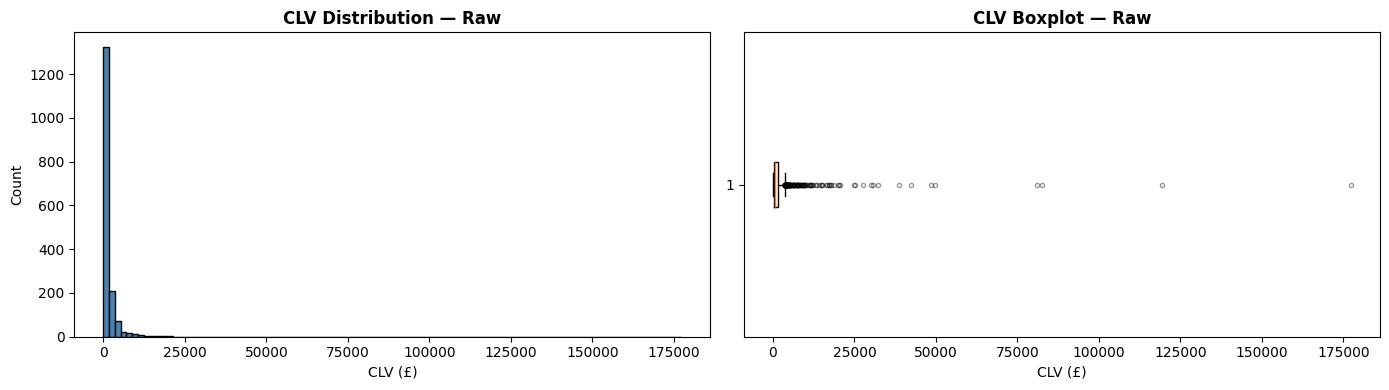

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(clv_df['clv_target'], bins=100,
             color='steelblue', edgecolor='black')
axes[0].set_title('CLV Distribution — Raw', fontweight='bold')
axes[0].set_xlabel('CLV (£)')
axes[0].set_ylabel('Count')

# Boxplot
axes[1].boxplot(clv_df['clv_target'], vert=False,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[1].set_title('CLV Boxplot — Raw', fontweight='bold')
axes[1].set_xlabel('CLV (£)')

plt.tight_layout()
plt.show()

In [ ]:
# Basic stats
print("=== CLV TARGET STATISTICS ===")
print(f"Count:    {len(clv_df['clv_target']):,}")
print(f"Mean:     £{clv_df['clv_target'].mean():,.2f}")
print(f"Median:   £{clv_df['clv_target'].median():,.2f}")
print(f"Std:      £{clv_df['clv_target'].std():,.2f}")

print(f"\n=== SKEWNESS & KURTOSIS ===")
print(f"Skewness:  {skew(clv_df['clv_target']):.3f}")
print(f"Kurtosis:  {kurtosis(clv_df['clv_target']):.3f}")

print(f"\n=== PERCENTILE BREAKDOWN ===")
percentiles = [25, 50, 75, 90, 95, 99, 99.9]
for p in percentiles:
    print(f"  p{p:<5} £{clv_df['clv_target'].quantile(p/100):,.2f}")
print(f"  Max    £{clv_df['clv_target'].max():,.2f}")

print(f"\n=== OUTLIER ANALYSIS (IQR METHOD) ===")
q1  = clv_df['clv_target'].quantile(0.25)
q3  = clv_df['clv_target'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
lower_fence = q1 - 1.5 * iqr

n_outliers = (clv_df['clv_target'] > upper_fence).sum()
outlier_revenue = clv_df[clv_df['clv_target'] > upper_fence]['clv_target'].sum()
total_revenue = clv_df['clv_target'].sum()

print(f"  IQR:          £{iqr:,.2f}")
print(f"  Upper fence:  £{upper_fence:,.2f}")
print(f"  Outliers:     {n_outliers} ({n_outliers/len(clv_df):.1%} of customers)")
print(f"  Outlier revenue: £{outlier_revenue:,.2f} ({outlier_revenue/total_revenue:.1%} of total)")

=== CLV TARGET STATISTICS ===
Count:    1,692
Mean:     £1,825.73
Median:   £684.70
Std:      £6,798.83

=== SKEWNESS & KURTOSIS ===
Skewness:  16.118
Kurtosis:  340.221

=== PERCENTILE BREAKDOWN ===
  p25    £199.11
  p50    £684.70
  p75    £1,564.38
  p90    £3,341.55
  p95    £5,342.77
  p99    £18,962.75
  p99.9  £93,811.63
  Max    £177,334.14

=== OUTLIER ANALYSIS (IQR METHOD) ===
  IQR:          £1,365.27
  Upper fence:  £3,612.28
  Outliers:     155 (9.2% of customers)
  Outlier revenue: £1,820,553.13 (58.9% of total)


# CLV TARGET DISTRIBUTION — ANALYSIS:

**Basic Statistics:**

 Mean £1,825 vs Median £684 — the mean is 2.7x higher than the median.
 When mean is significantly higher than median it means a small number
 of very high spenders are pulling the average up. The standard deviation
 of £6,798 is almost 4x the mean, meaning the spread of values is enormous.
 A typical customer is worth £684 but the average gets dragged to £1,825
 by outliers alone.

**Skewness & Kurtosis:**

 Skewness of 16.1 is extreme — anything above 1 is considered high,
 above 3 is severe. At 16 this is one of the most skewed distributions
 encountered in practice, almost entirely driven by the £177,334 customer.
 Kurtosis of 340 means the distribution has an extraordinarily heavy tail.
 Normal distribution has kurtosis of 3 — at 340 the extreme values are
 not just large, they exist in a completely different league from the
 rest of the customer base.

**Percentile Breakdown:**

 The bottom quarter of customers spent less than £199.
 Half the customer base spent less than £684.
 The top 10% spent above £3,341.
 The critical finding is in the tail — p99 is £18,962 but p99.9 jumps
 to £93,811 and the maximum is £177,334. The gap between the 99th and
 99.9th percentile alone is £75,000. The top 0.1% of customers are in
 a completely different universe from everyone else.

**Outlier Analysis:**

 155 customers (9.2%) account for £1,820,553 — 58.9% of all future revenue.
 This is more extreme than the classic 80/20 Pareto rule, closer to 90/10.
 These 155 customers are the single most important segment in the dataset
 from a revenue protection standpoint.

 Modeling Implication
 Skewness of 16 combined with kurtosis of 340 means raw CLV values cannot
 be fed directly into a regression model. The £177,334 outlier would
 dominate the loss function — the model would twist itself trying to predict
 that one customer correctly at the expense of accurate predictions for everyone else. Log transformation of the target variable is required
 before modeling to compress the distribution into a learnable range. Predictions will be made in log space and exponentiated back to pounds
 for business interpretation.

=== ZERO vs NON-ZERO SPLIT ===
Zero spend customers:     307 (18.1%)
Non-zero spend customers: 1,385 (81.9%)

=== ZERO CUSTOMER PROFILE vs NON-ZERO ===
                Zero CLV  Non-zero CLV  difference_%
recency           68.068        43.003         -36.8
frequency          2.951         5.129          73.8
monetary        1173.333      2468.112         110.4
months_active      2.225         3.222          44.8
active_last_60     0.502         0.750          49.5
spend_trend        0.795         1.175          47.8

=== MODELING IMPLICATION ===
Zero customers represent 18.1% of data
They contribute £0 to future revenue
Non-zero customers represent 81.9% of data
They generate £3,089,132.10 in future revenue


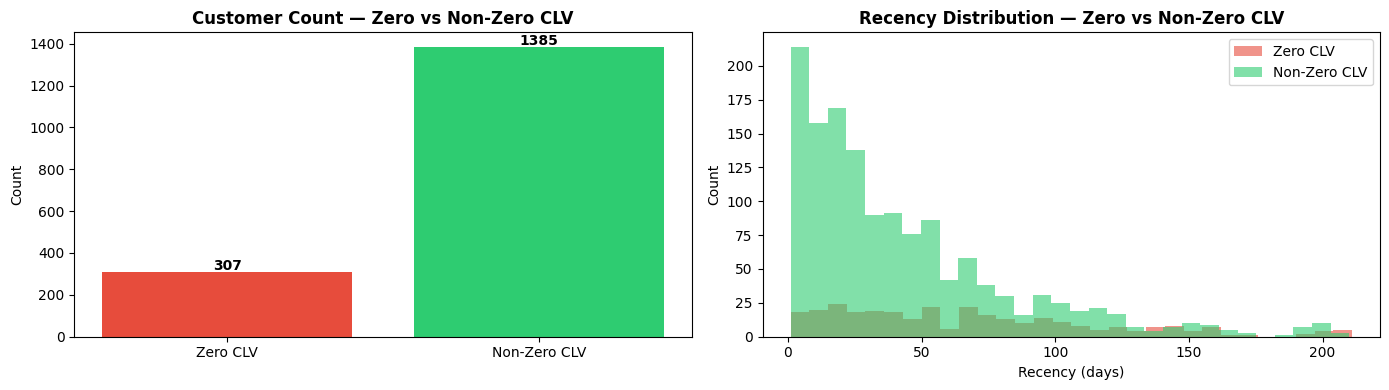

In [ ]:
# ============================================================
# CLV TARGET — ZERO SPEND ANALYSIS
# ============================================================

clv_zeros    = clv_df[clv_df['clv_target'] == 0]
clv_nonzero  = clv_df[clv_df['clv_target'] > 0]

print("=== ZERO vs NON-ZERO SPLIT ===")
print(f"Zero spend customers:     {len(clv_zeros):,} ({len(clv_zeros)/len(clv_df):.1%})")
print(f"Non-zero spend customers: {len(clv_nonzero):,} ({len(clv_nonzero)/len(clv_df):.1%})")

print(f"\n=== ZERO CUSTOMER PROFILE vs NON-ZERO ===")
compare_cols = ['recency', 'frequency', 'monetary',
                'months_active', 'active_last_60', 'spend_trend']

comparison = pd.DataFrame({
    'Zero CLV':     clv_zeros[compare_cols].mean(),
    'Non-zero CLV': clv_nonzero[compare_cols].mean()
})
comparison['difference_%'] = (
    (comparison['Non-zero CLV'] - comparison['Zero CLV'])
    / comparison['Zero CLV'] * 100
).round(1)

print(comparison.round(3).to_string())

print(f"\n=== MODELING IMPLICATION ===")
print(f"Zero customers represent {len(clv_zeros)/len(clv_df):.1%} of data")
print(f"They contribute £0 to future revenue")
print(f"Non-zero customers represent {len(clv_nonzero)/len(clv_df):.1%} of data")
print(f"They generate £{clv_nonzero['clv_target'].sum():,.2f} in future revenue")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart zero vs non-zero
axes[0].bar(['Zero CLV', 'Non-Zero CLV'],
            [len(clv_zeros), len(clv_nonzero)],
            color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Customer Count — Zero vs Non-Zero CLV', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([len(clv_zeros), len(clv_nonzero)]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Recency comparison — zero vs non-zero
axes[1].hist(clv_zeros['recency'], bins=30, alpha=0.6,
             color='#e74c3c', label='Zero CLV')
axes[1].hist(clv_nonzero['recency'], bins=30, alpha=0.6,
             color='#2ecc71', label='Non-Zero CLV')
axes[1].set_title('Recency Distribution — Zero vs Non-Zero CLV', fontweight='bold')
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

## CLV Target — Zero Spend Analysis Findings

### Zero vs Non-Zero Split:

307 customers (18.1%) generated zero revenue in the prediction window — these are customers who churned and never returned. The remaining 1,385 customers (81.9%) generated £3,089,132 in future revenue. The modeling challenge is predicting near-zero values for the 307 while accurately estimating spend for the 1,385.

### Behavioral Separation — Zero vs Non-Zero Customers:

Every single feature separates zero from non-zero customers in the expected direction, which is strong evidence the features contain genuine predictive signal.

**Recency (+36.8% higher for zero CLV customers):**

Zero CLV customers last purchased 68 days before the window ended vs 43 days for returning customers. Customers going quiet near the end of the observation window are significantly more likely to have zero future spend.

**Frequency (73.8% lower for zero CLV customers):**

Returning customers placed nearly double the orders — 5.1 vs 2.9. This is the strongest separation signal in the table. Purchasing habit during the observation window is the best predictor of purchasing habit in the future.

**Monetary (110.4% lower for zero CLV customers):**

Customers who returned had spent more than double during the observation window — £2,468 vs £1,173. Higher historical spend predicts higher future spend. The magnitude of this difference confirms monetary value as a core CLV driver.

**Months Active (44.8% lower for zero CLV customers):**

Zero CLV customers were only active for 2.2 of 7 possible months. Returning customers were active for 3.2 months. Consistent engagement across the observation window predicts future engagement.

**Active Last 60 Days (49.5% lower for zero CLV customers):**

Only 50% of zero CLV customers were active in the final 60 days of the observation window vs 75% of returning customers. Late window inactivity is a reliable early warning signal for zero future spend.

**Spend Trend (47.8% lower for zero CLV customers):**

Zero CLV customers showed declining spend momentum — spending less in the second half of the observation window than the first (0.79). Returning customers showed increasing momentum (1.17). Customers whose spending was accelerating were significantly more likely to return.

### Modeling Implication
The clear and consistent behavioral separation across all six features means a single regression model trained on the full 1,692 customers should be capable of learning the zero vs non-zero distinction without requiring a separate two-stage architecture. The features are doing their job — the model needs to learn that high recency combined with low frequency, low monetary value, and declining spend trend predicts near-zero future CLV. A two-stage model remains a valid future improvement but is not necessary given the strength of the existing feature signal.

Top 1% of customers ( 16 people) → 28.2% of revenue
Top 5% of customers ( 84 people) → 49.3% of revenue
Top 10% of customers (169 people) → 60.6% of revenue
Top 20% of customers (338 people) → 74.4% of revenue
Top 30% of customers (507 people) → 83.0% of revenue
Top 50% of customers (846 people) → 93.6% of revenue

Total future revenue: £3,089,132.10


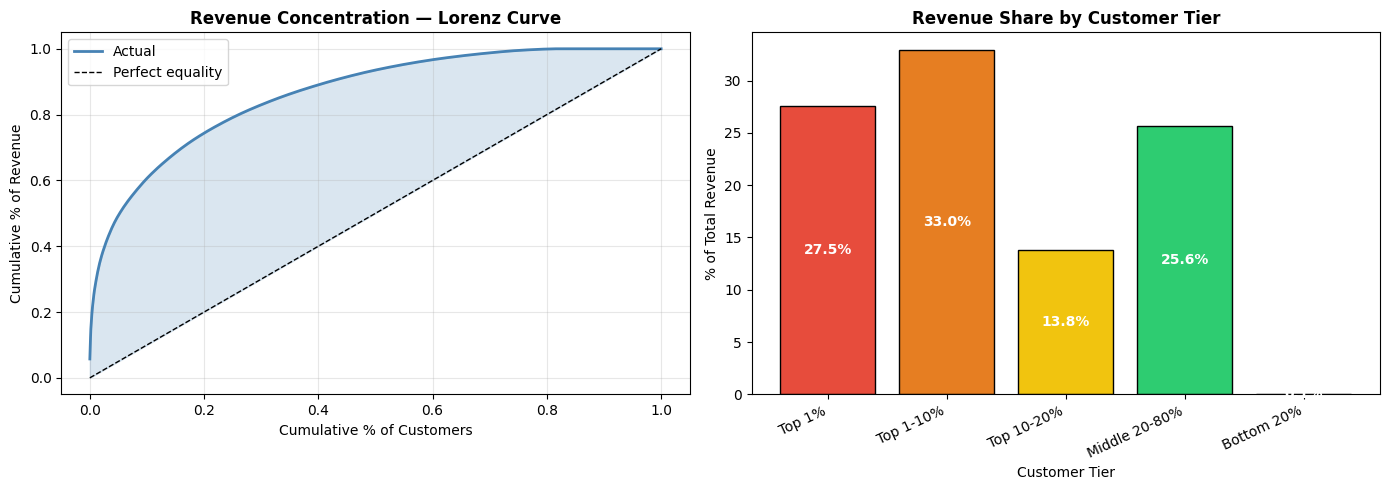

In [ ]:
# ============================================================
# CLV TARGET — REVENUE CONCENTRATION
# ============================================================

# Sort customers by CLV descending
clv_sorted = clv_df['clv_target'].sort_values(ascending=False).reset_index(drop=True)
total_rev   = clv_sorted.sum()
n           = len(clv_sorted)

# Cumulative revenue at each percentile
cum_rev = clv_sorted.cumsum() / total_rev

# Key concentration points
for pct in [0.01, 0.05, 0.10, 0.20, 0.30, 0.50]:
    idx     = int(pct * n)
    rev_pct = cum_rev.iloc[idx]
    print(f"Top {pct:.0%} of customers ({idx:>3} people) → {rev_pct:.1%} of revenue")

print(f"\nTotal future revenue: £{total_rev:,.2f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lorenz curve
x = np.linspace(0, 1, n)
axes[0].plot(x, cum_rev.values, color='steelblue', linewidth=2, label='Actual')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect equality')
axes[0].fill_between(x, cum_rev.values, x, alpha=0.2, color='steelblue')
axes[0].set_title('Revenue Concentration — Lorenz Curve', fontweight='bold')
axes[0].set_xlabel('Cumulative % of Customers')
axes[0].set_ylabel('Cumulative % of Revenue')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar chart — revenue by tier
tiers = {
    'Top 1%':       clv_sorted.iloc[:int(0.01*n)].sum(),
    'Top 1-10%':    clv_sorted.iloc[int(0.01*n):int(0.10*n)].sum(),
    'Top 10-20%':   clv_sorted.iloc[int(0.10*n):int(0.20*n)].sum(),
    'Middle 20-80%':clv_sorted.iloc[int(0.20*n):int(0.80*n)].sum(),
    'Bottom 20%':   clv_sorted.iloc[int(0.80*n):].sum()
}

pcts   = [v / total_rev * 100 for v in tiers.values()]
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#95a5a6']

bars = axes[1].bar(tiers.keys(), pcts, color=colors, edgecolor='black')
axes[1].bar_label(bars, labels=[f'{p:.1f}%' for p in pcts],
                  label_type='center', fontweight='bold', color='white')
axes[1].set_title('Revenue Share by Customer Tier', fontweight='bold')
axes[1].set_ylabel('% of Total Revenue')
axes[1].set_xlabel('Customer Tier')
plt.xticks(rotation=25, ha='right')

plt.tight_layout()
plt.show()

# CLV Target — EDA Summary

## What We Did and Why

Before building any model we need to understand what we are trying to predict. The CLV target is the actual spend per customer in the prediction window July to December 2010. We analyzed it across four dimensions — raw distribution, zero spend customers, revenue concentration, and transformation selection. Each dimension answers a specific question that directly affects modeling decisions.

---

## Step 1 — Raw Distribution

**What we did:** Plotted the raw histogram and boxplot of CLV values across all 1,692 customers.

**What we found:** The distribution is extremely right skewed with a dense cluster of customers near zero and a long tail stretching to £177,334. The boxplot shows the vast majority of customers sit below £5,000 with a handful of extreme outliers far beyond the upper fence.

---

## Step 2 — Statistics, Skewness and Outliers

**What we did:** Computed key statistics, skewness, kurtosis, percentile breakdown and IQR-based outlier analysis.

**What we found:**

| Metric | Value |
|--------|-------|
| Mean | £1,825 |
| Median | £684 |
| Std | £6,798 |
| Skewness | 16.1 |
| Kurtosis | 340.2 |

**Mean vs Median:** Mean is 2.7x higher than the median. When mean significantly exceeds median a small number of very high spenders are pulling the average up. The standard deviation of £6,798 is almost 4x the mean — the spread of values is enormous.

**Skewness of 16.1** is extreme. Anything above 1 is considered high, above 3 is severe. At 16 this is one of the most skewed distributions encountered in practice, almost entirely driven by the £177,334 customer.

**Kurtosis of 340** means the distribution has an extraordinarily heavy tail. A normal distribution has kurtosis of 3. At 340 the extreme values are not just large — they exist in a completely different league from the rest of the customer base.

**Percentile breakdown:**
The bottom quarter of customers spent less than £199. Half spent less than £684. The critical finding is in the tail — p99 is £18,962 but p99.9 jumps to £93,811 and the maximum is £177,334. The gap between the 99th and 99.9th percentile alone is £75,000.

**Outlier analysis:**
155 customers (9.2%) sitting above the IQR upper fence of £3,612 account for £1,820,553 — 58.9% of all future revenue. This is more extreme than the classic 80/20 Pareto rule.

---

## Step 3 — Zero Spend Analysis

**What we did:** Separated customers with zero future spend from those with positive spend and compared their behavioral profiles across six key features.

**What we found:**

| Feature | Zero CLV | Non-Zero CLV | Difference |
|---------|----------|--------------|------------|
| Recency (days) | 68.1 | 43.0 | +36.8% higher |
| Frequency (orders) | 2.95 | 5.13 | 73.8% lower |
| Monetary (£) | 1,173 | 2,468 | 110.4% lower |
| Months Active | 2.2 | 3.2 | 44.8% lower |
| Active Last 60 | 0.50 | 0.75 | 49.5% lower |
| Spend Trend | 0.79 | 1.18 | 47.8% lower |

Every single feature separates zero from non-zero customers in the expected direction. Zero CLV customers were less recent, ordered less frequently, spent less, were active fewer months, went quiet near the end of the window, and showed declining spend momentum. This is strong evidence that the features contain genuine predictive signal — the model has clear behavioral differences to learn from.

**Modeling implication:** The clear separation means a single regression model trained on all 1,692 customers should be capable of distinguishing churned customers from returning ones without requiring a two-stage architecture. A two-stage model remains a valid future improvement but is not necessary at this stage.

---

## Step 4 — Revenue Concentration

**What we did:** Computed cumulative revenue contribution by customer percentile and visualized it as a Lorenz curve and tier bar chart.

**What we found:**

| Customer Group | People | Revenue Share |
|---------------|--------|---------------|
| Top 1% | 16 | 28.2% |
| Top 5% | 84 | 49.3% |
| Top 10% | 169 | 60.6% |
| Top 20% | 338 | 74.4% |
| Top 30% | 507 | 83.0% |
| Top 50% | 846 | 93.6% |

16 customers generate 28% of all future revenue. 84 customers control half. The bottom 50% of customers generate only 6.4% of total revenue combined. This is more extreme than the classic 80/20 Pareto rule.

The Lorenz curve hugs the bottom right corner before shooting up steeply — the visual signature of extreme revenue concentration. The bar chart shows revenue living almost entirely in the top customer tiers.

**Modeling implication:** Standard error metrics like MAE and RMSE will be dominated by how well the model predicts the top customers. Getting one £50,000 customer wrong swamps getting 500 regular customers exactly right. This concentration reinforces the decision to log transform the target — it stops the top customers from monopolizing the model's attention during training. Business metrics must use a tier system rather than aggregate averages to tell the true story.

---

## Key Decisions Made From This EDA

**Decision 1 — Yeo-Johnson the target for linear models**
Skewness of 16.1 and kurtosis of 340 make raw CLV unpredictable for Linear Regression which assumes normally distributed errors. Log transformation compresses the distribution into a learnable range. Predictions will be made in log space and exponentiated back to pounds for business interpretation.

**Decision 2 — Test raw target for tree based models**
Random Forest and XGBoost use rank based splits not distance based — they can handle skewed targets more naturally. Both raw and log transformed targets will be tested for tree models and compared directly.

**Decision 3 — Single regression architecture**
The strong behavioral separation between zero and non-zero customers means a single model trained on all 1,692 customers is sufficient. A two-stage classifier plus regressor is noted as a future improvement.

**Decision 4 — Business metrics must use tiers**
Given that 16 customers control 28% of future revenue, aggregate metrics alone are misleading. Model evaluation will include tier-level accuracy — how well does the model predict the top 10% versus the middle 60% versus the bottom 30%.

---

## What Is Coming Next

**Stage 3 — Preprocessing and Pipeline**
Apply Yeo-Johnson to the 10 skewed features exactly as in the churn pipeline. Add log transformation of the target for linear models. Build ColumnTransformer and Pipeline. Train test split with random state 42.

**Stage 4 — Baseline Model**
Predict the mean CLV for every customer. This is the floor every model must beat. Without a baseline there is no reference point for whether the model is adding value.

**Stage 5 — Model Training**
Linear Regression, Random Forest Regressor, XGBoost Regressor evaluated on MAE, RMSE and R². Tree models tested on both raw and log transformed targets.

**Stage 6 — Business Metrics and Tier Analysis**
CLV tier system — High Value, Medium Value, Low Value, Zero. Revenue capture per tier. Which customers the model predicts well and which it struggles with.

**Stage 7 — Action Matrix**
Combine CLV predictions with churn probabilities from the churn model to build a four quadrant priority matrix — the most client facing output in the entire project.

# EDA Features


Number of features: 17
Features: ['recency', 'frequency', 'monetary', 'unique_products', 'avg_quantity', 'customer_lifespan', 'avg_order_value', 'avg_days_between_orders', 'early_spend', 'late_spend', 'return_count', 'months_active', 'active_last_30', 'active_last_60', 'new_in_late_window', 'spend_trend', 'return_rate']

Spearman correlation (absolute value sorted):
  monetary                    +0.612   (abs = 0.612)
  late_spend                  +0.566   (abs = 0.566)
  months_active               +0.484   (abs = 0.484)
  frequency                   +0.478   (abs = 0.478)
  avg_order_value             +0.439   (abs = 0.439)
  early_spend                 +0.411   (abs = 0.411)
  unique_products             +0.377   (abs = 0.377)
  customer_lifespan           +0.376   (abs = 0.376)
  recency                     -0.310   (abs = 0.310)
  return_count                +0.288   (abs = 0.288)
  active_last_60              +0.264   (abs = 0.264)
  active_last_30              +0.263   (abs = 0.

/tmp/ipykernel_7783/3796260502.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spearman_corr_sorted_plot.values,


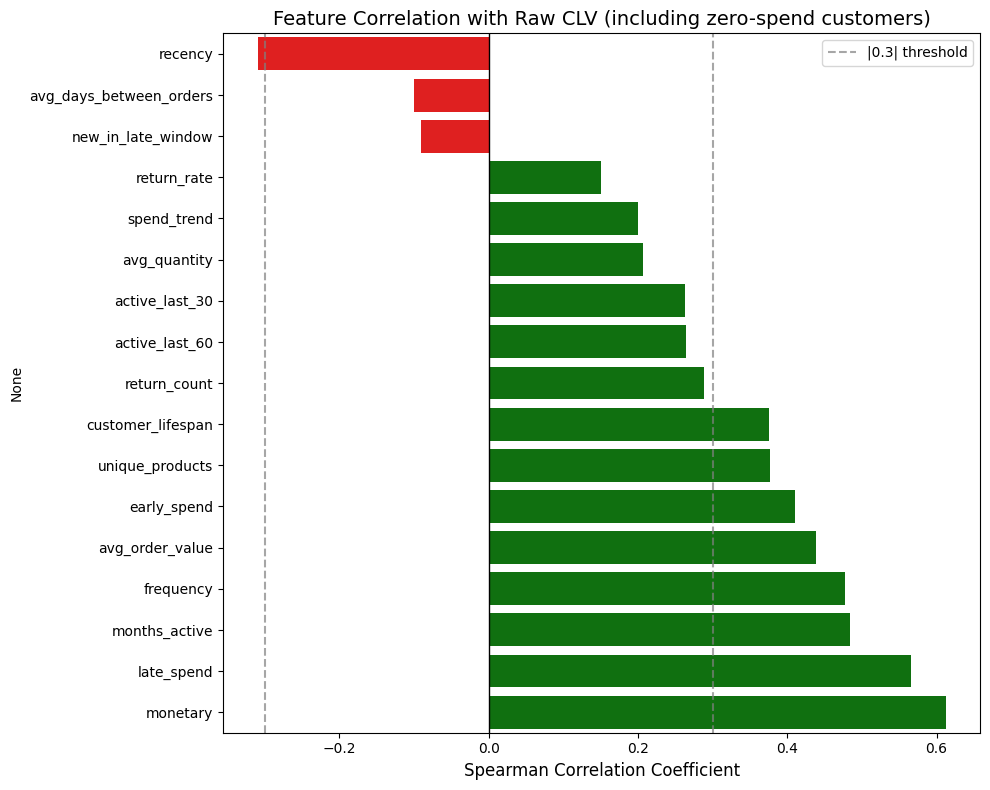

In [ ]:
# Spearman correlation with clv_target

# Define features
feature_cols = [col for col in clv_df.columns if col not in ['CustomerID', 'clv_target']]

print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}\n")

# Computing Spearman
spearman_corr = clv_df[feature_cols + ['clv_target']].corr(method='spearman')['clv_target'].drop('clv_target')

# sort by absolute value for better readability
spearman_corr_sorted = spearman_corr.abs().sort_values(ascending=False)
print("Spearman correlation (absolute value sorted):")
for feat, corr in spearman_corr_sorted.items():
  print(f"  {feat:25s} {spearman_corr[feat]:+8.3f}   (abs = {corr:.3f})")


# Print summary Stats

print("\n" + "="*60)
print("Summary:")
print(f"  Features with |correlation| > 0.3: {sum(abs(spearman_corr) > 0.3)}")
print(f"  Features with |correlation| > 0.5: {sum(abs(spearman_corr) > 0.5)}")
print(f"  Top positive: {spearman_corr.idxmax()} ({spearman_corr.max():.3f})")
print(f"  Most negative: {spearman_corr.idxmin()} ({spearman_corr.min():.3f})")


# Horizontal bar chart
plt.figure(figsize=(10, 8))
# Sort for plotting (ascending so top positive appears at top)
spearman_corr_sorted_plot = spearman_corr.sort_values(ascending=True)
colors = ['red' if x < 0 else 'green' for x in spearman_corr_sorted_plot]
sns.barplot(x=spearman_corr_sorted_plot.values,
            y=spearman_corr_sorted_plot.index,
            palette=colors,
            orient='h')
plt.axvline(0, color='black', linewidth=1)
plt.axvline(0.3, color='gray', linestyle='--', alpha=0.7, label='|0.3| threshold')
plt.axvline(-0.3, color='gray', linestyle='--', alpha=0.7)
plt.xlabel('Spearman Correlation Coefficient', fontsize=12)
plt.title('Feature Correlation with Raw CLV (including zero-spend customers)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


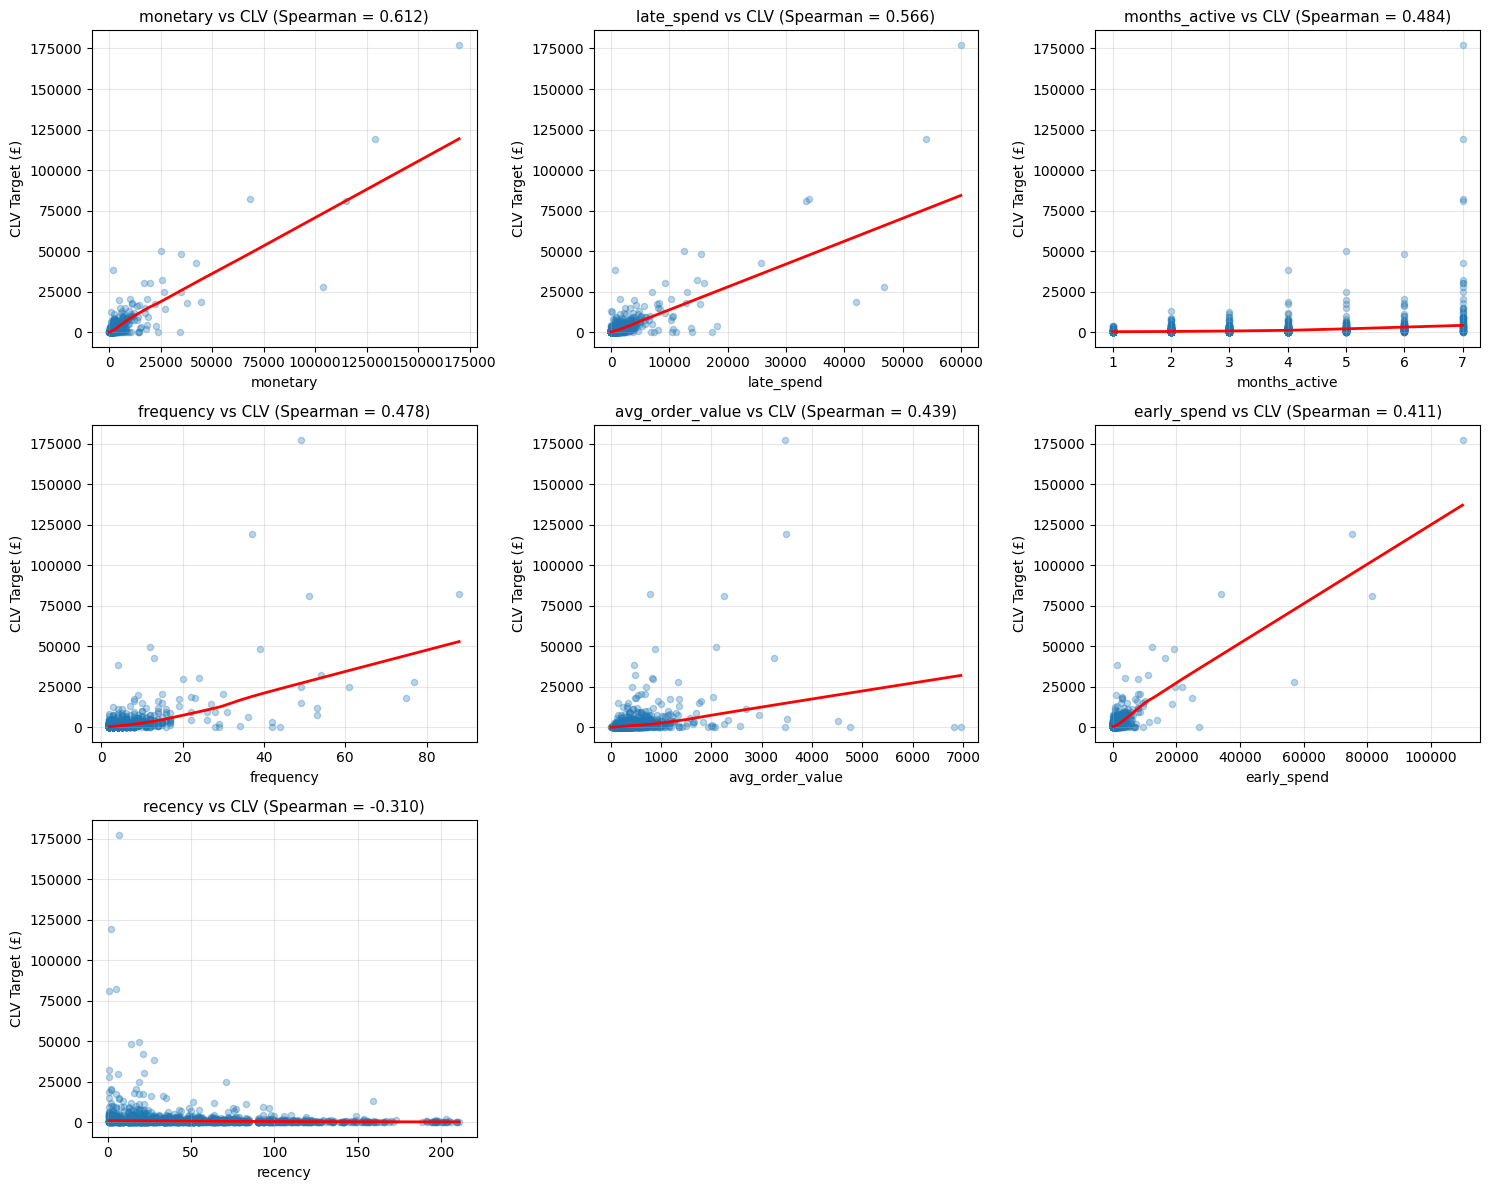

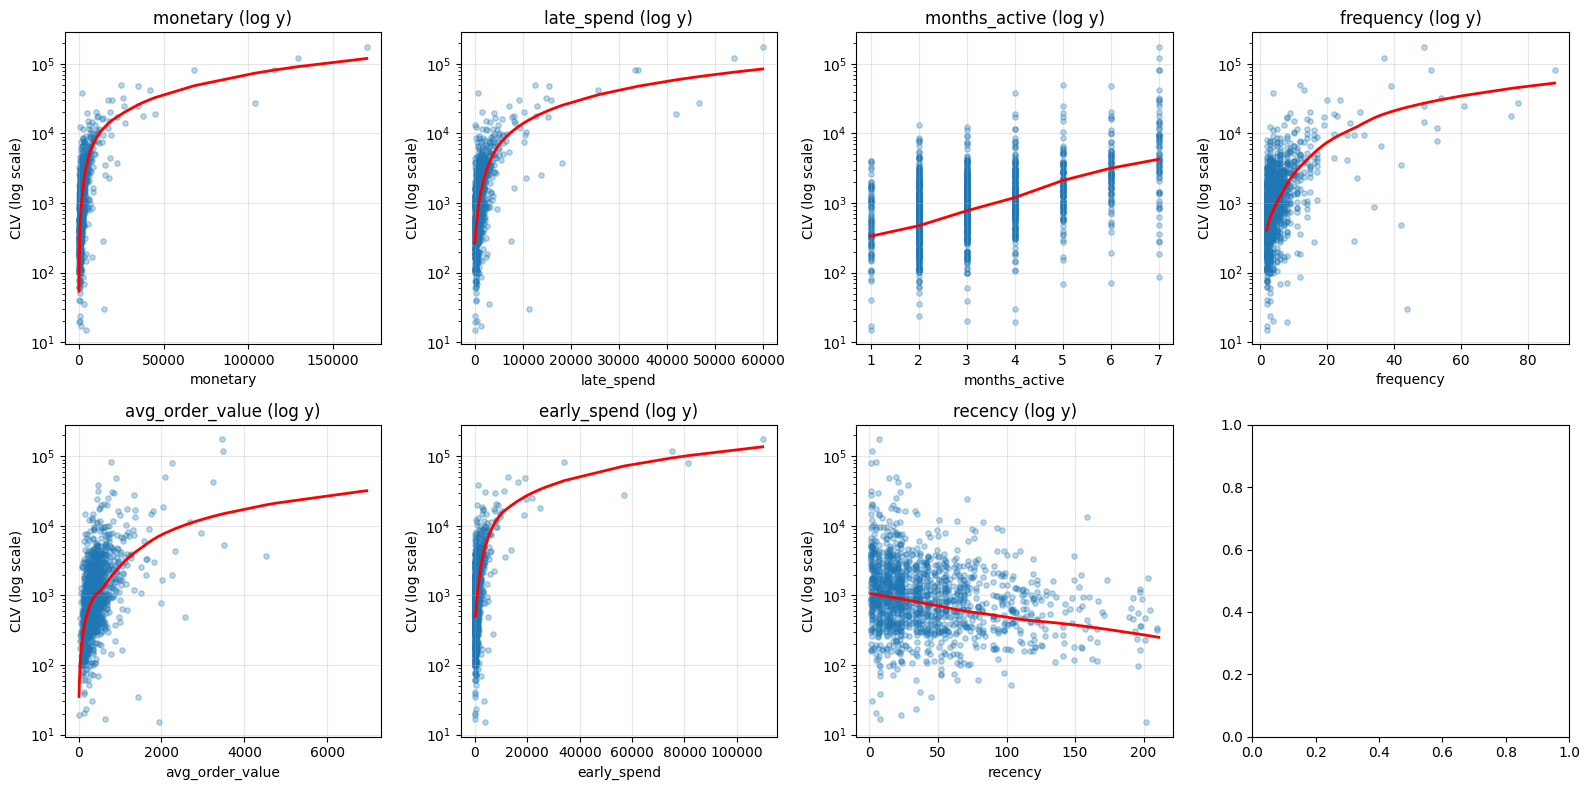

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select top features (abs correlation > 0.4 plus recency as negative example)
top_features = ['monetary', 'late_spend', 'months_active', 'frequency',
                'avg_order_value', 'early_spend', 'recency']

# Create subplots: 3 rows, 3 columns (fits 7 plots)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    ax = axes[i]

    # Scatter plot with jitter (optional, for integer features)
    # Use alpha for transparency to see density
    ax.scatter(clv_df[feature], clv_df['clv_target'], alpha=0.3, s=20)

    # Add a LOWESS trend line (robust to outliers)
    # Sort x for clean line
    x_sorted = np.sort(clv_df[feature].values)
    # Use numpy polyfit with low degree (1 for linear, 2 for quadratic)
    # Better: use seaborn regplot but we'll do manual for control
    sns.regplot(x=clv_df[feature], y=clv_df['clv_target'],
                scatter=False, color='red', ax=ax, lowess=True, line_kws={'linewidth': 2})

    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('CLV Target (£)', fontsize=10)
    ax.set_title(f'{feature} vs CLV (Spearman = {spearman_corr[feature]:.3f})', fontsize=11)
    ax.grid(True, alpha=0.3)

# Remove unused subplot (9th)
fig.delaxes(axes[7])
fig.delaxes(axes[8])

plt.tight_layout()
plt.show()

# Optional: Log-scale version for skewed features
# Create a second set of plots with log y-axis to see low-end structure
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 8))
axes2 = axes2.flatten()
for i, feature in enumerate(top_features[:8]):  # first 8
    ax = axes2[i]
    ax.scatter(clv_df[feature], clv_df['clv_target'], alpha=0.3, s=15)
    ax.set_yscale('log')
    sns.regplot(x=clv_df[feature], y=clv_df['clv_target'],
                scatter=False, color='red', ax=ax, lowess=True, line_kws={'linewidth': 2})
    ax.set_xlabel(feature)
    ax.set_ylabel('CLV (log scale)')
    ax.set_title(f'{feature} (log y)')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

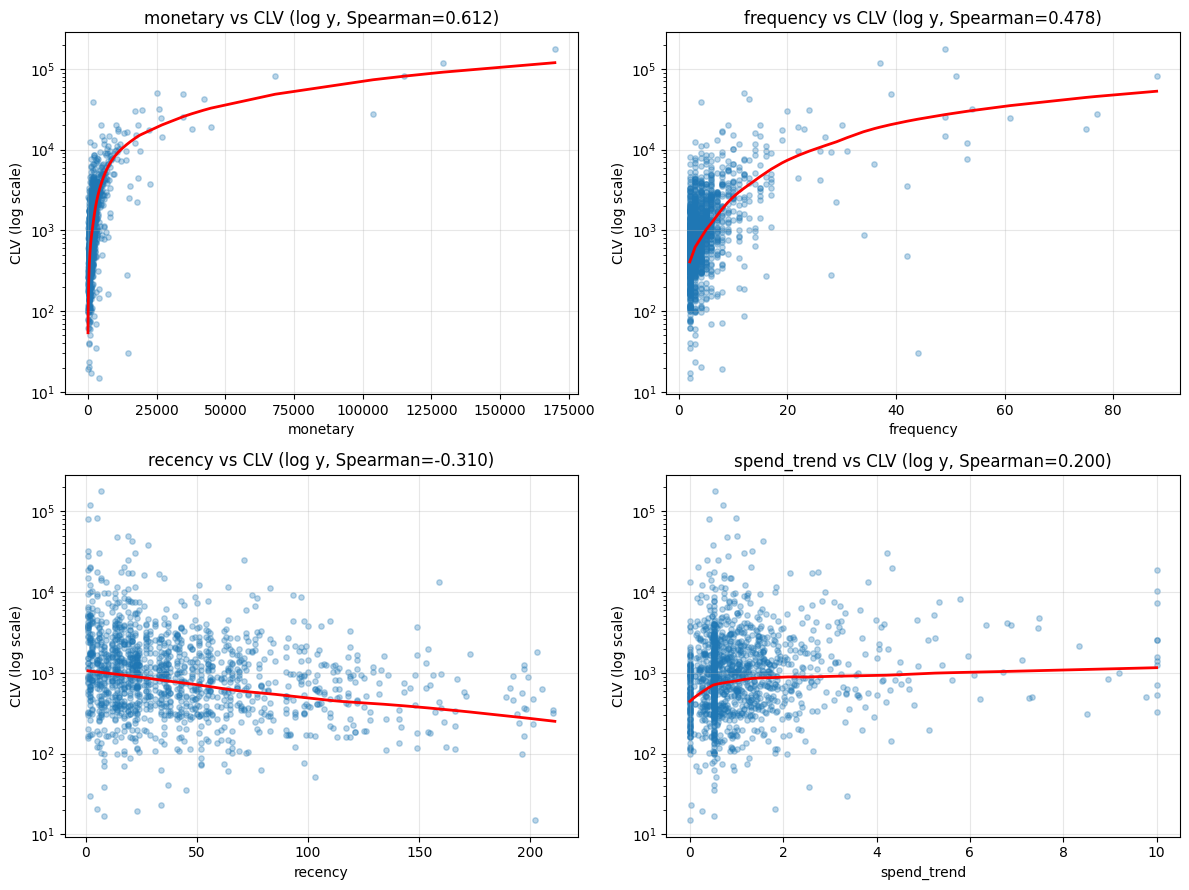

In [ ]:
# Focused log-scale scatter — monetary, frequency, recency, spend_trend (for report)
report_scatter_features = ['monetary', 'frequency', 'recency', 'spend_trend']

fig3, axes3 = plt.subplots(2, 2, figsize=(12, 9))
axes3 = axes3.flatten()

for i, feature in enumerate(report_scatter_features):
    ax = axes3[i]
    ax.scatter(clv_df[feature], clv_df['clv_target'], alpha=0.3, s=15)
    ax.set_yscale('log')
    sns.regplot(x=clv_df[feature], y=clv_df['clv_target'],
                scatter=False, color='red', ax=ax, lowess=True, line_kws={'linewidth': 2})
    ax.set_xlabel(feature)
    ax.set_ylabel('CLV (log scale)')
    ax.set_title(f'{feature} vs CLV (log y, Spearman={spearman_corr[feature]:.3f})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

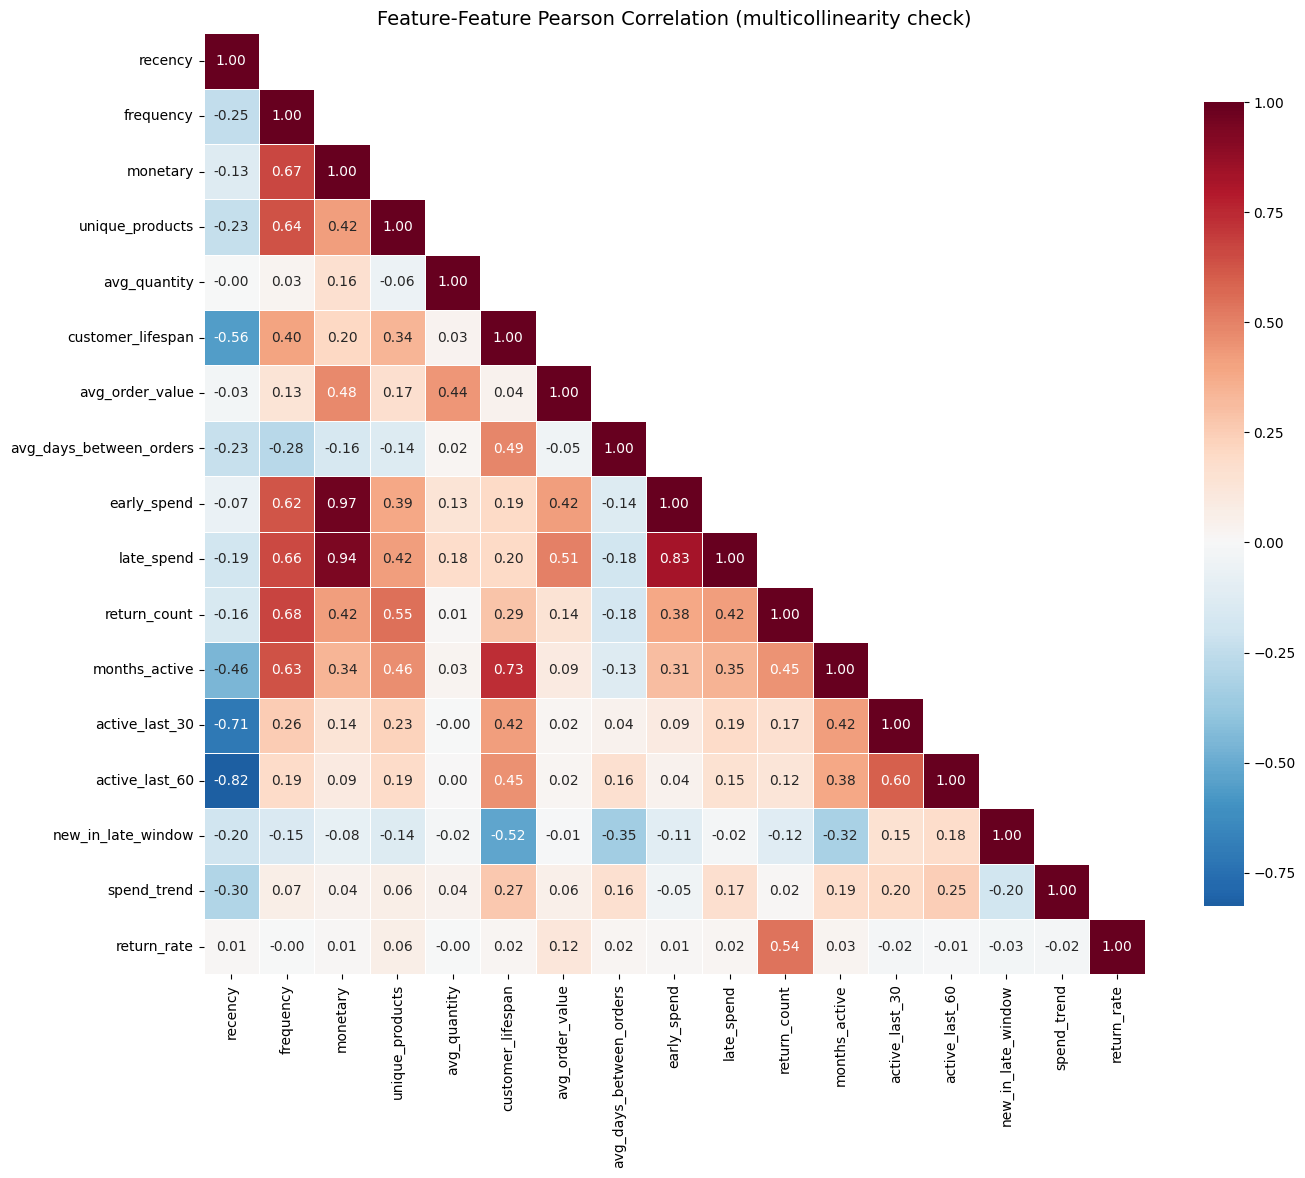


Highly correlated pairs (|r| > 0.85):
  monetary & early_spend: 0.969
  monetary & late_spend: 0.940


In [ ]:
# Compute Pearson correlation between features (not including target)
feature_corr = clv_df[feature_cols].corr(method='pearson')

# Create mask for upper triangle (to avoid double vision)
mask = np.triu(np.ones_like(feature_corr, dtype=bool), k=1)

plt.figure(figsize=(14, 12))
sns.heatmap(feature_corr, mask=mask, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature-Feature Pearson Correlation (multicollinearity check)', fontsize=14)
plt.tight_layout()
plt.show()

# Print highly correlated pairs (>0.85)
high_corr = []
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        if abs(feature_corr.iloc[i, j]) > 0.85:
            high_corr.append((feature_corr.columns[i], feature_corr.columns[j], feature_corr.iloc[i, j]))

print("\nHighly correlated pairs (|r| > 0.85):")
for pair in high_corr:
    print(f"  {pair[0]} & {pair[1]}: {pair[2]:.3f}")

In [ ]:
# Create CLV tiers
clv_df_tier = clv_df.copy()

# Define tiers
conditions = [
    clv_df_tier['clv_target'] == 0,
    (clv_df_tier['clv_target'] > 0) & (clv_df_tier['clv_target'] <= clv_df_tier[clv_df_tier['clv_target'] > 0]['clv_target'].quantile(0.33)),
    (clv_df_tier['clv_target'] > clv_df_tier[clv_df_tier['clv_target'] > 0]['clv_target'].quantile(0.33)) &
    (clv_df_tier['clv_target'] <= clv_df_tier[clv_df_tier['clv_target'] > 0]['clv_target'].quantile(0.67)),
    clv_df_tier['clv_target'] > clv_df_tier[clv_df_tier['clv_target'] > 0]['clv_target'].quantile(0.67)
]
labels = ['Zero', 'Low', 'Mid', 'High']
clv_df_tier['clv_tier'] = np.select(conditions, labels, default='Zero')

# Calculate mean of each feature per tier (excluding the redundant ones)
features_for_tier = [f for f in feature_cols if f not in ['early_spend', 'late_spend']]
tier_means = clv_df_tier.groupby('clv_tier')[features_for_tier].mean().round(2)

# Reorder tiers logically
tier_order = ['Zero', 'Low', 'Mid', 'High']
tier_means = tier_means.reindex(tier_order)

print("Feature means by CLV tier:")
print(tier_means.T)

# Also show percentage lift from Low to High
print("\n" + "="*60)
print("Lift from Low tier to High tier (High/Low ratio):")
low_means = tier_means.loc['Low']
high_means = tier_means.loc['High']
lift = (high_means / low_means).round(2).sort_values(ascending=False)
print(lift)

Feature means by CLV tier:
clv_tier                    Zero     Low      Mid     High
recency                    68.07   54.51    43.32    31.17
frequency                   2.95    3.30     4.00     8.12
monetary                 1173.33  841.91  1298.00  5300.27
unique_products            42.54   49.58    69.02   105.90
avg_quantity               28.59   16.30    21.31    35.93
customer_lifespan          82.18   96.77   116.19   142.02
avg_order_value           373.93  265.22   351.51   586.52
avg_days_between_orders    30.44   33.51    32.41    26.55
return_count                0.72    0.64     0.96     2.07
months_active               2.22    2.50     3.04     4.13
active_last_30              0.27    0.39     0.48     0.63
active_last_60              0.50    0.66     0.75     0.85
new_in_late_window          0.21    0.20     0.17     0.13
spend_trend                 0.80    1.00     1.16     1.37
return_rate                 0.22    0.19     0.24     0.27

Lift from Low tier to High t

## Feature EDA: Correlation Analysis and Decisions

### What We Did and Why
Before modeling, we need to verify that features built for churn prediction carry genuine signal for a regression target. A feature that predicts whether someone leaves does not automatically predict how much they spend. We ran four analyses to answer this specifically for CLV.

---

### Step 1 — Spearman Correlation: Features vs CLV Target

Spearman was chosen over Pearson because both the features and the raw CLV target are heavily right-skewed. Pearson measures linear correlation and is distorted by extreme values — a single £177,000 customer can dominate the entire calculation. Spearman converts values to ranks first, making it robust to skew and outliers.

**Findings:**

- 9 of 17 features clear the |0.3| meaningful threshold  
- Strongest signals:
  - `monetary` (0.612)
  - `late_spend` (0.566)
  - `months_active` (0.484)
  - `frequency` (0.478)
  - `avg_order_value` (0.439)
  - `early_spend` (0.411)

- `recency` is the only negative predictor (-0.310), meaning more recent customers tend to spend more in the future

- Near-zero features (weak signal):
  - `avg_days_between_orders` (-0.100)
  - `new_in_late_window` (-0.091)

These are flagged as potential dead weight pending model confirmation.

---

### Step 2 — Scatter Plots: Relationship Shape

We plotted the top 7 features against raw CLV on both linear and log y-axis scales to understand relationship shapes.

**Findings:**

- On a linear scale: relationships appear distorted with extreme whale customers dominating  
- On a log scale: relationships become smooth and structured  

This indicates a **log-linear (multiplicative) relationship**, not additive.

**Implication:**
Linear regression on raw CLV would underfit because it assumes additive relationships.  
Log transformation of the target is **validated by the data**, not just assumed.

---

### Step 3 — Feature-Feature Pearson Correlation: Multicollinearity Check

We computed a Pearson correlation matrix across all features to identify redundancy.

**Findings:**

- `monetary` & `early_spend`: **0.969**
- `monetary` & `late_spend`: **0.940**

These are near-perfect correlations.

**Interpretation:**
- `monetary` = total spend  
- `early_spend` + `late_spend` = components of that total  

Keeping all three:
- breaks linear model stability (multicollinearity)
- splits importance in tree models without adding signal

---

### Step 4 — Tier-Level Feature Means

Customers were split into four CLV tiers:
- Zero
- Low
- Mid
- High

We computed feature means per tier to understand behavioral differences.

**Findings:**

Most features show **monotonic increase from Zero → High**, confirming strong behavioral signal.

#### Key Lifts (Low → High Tier):

| Feature            | Low Tier | High Tier | Lift |
|------------------|----------|----------|------|
| monetary         | £842     | £5,300   | 6.3x |
| return_count     | 0.64     | 2.07     | 3.2x |
| frequency        | 3.30     | 8.12     | 2.5x |
| avg_order_value  | £265     | £587     | 2.2x |
| unique_products  | 49.6     | 105.9    | 2.1x |

**Interpretation:**
High-value customers:
- spend more per order
- buy more frequently
- purchase more diverse products
- show increasing spend momentum

`recency` decreases across tiers (0.57x), confirming:
→ more recent activity = higher future value

**Non-monotonic features:**
- `avg_quantity`
- `avg_days_between_orders`

These align with their weak correlation signals.

---

## Decisions Made From This EDA

### Decision 1 — Drop `early_spend` and `late_spend`
- High correlation with `monetary` (0.97, 0.94)
- Redundant information
- Causes instability in linear models

→ Feature set reduced from 17 → 15

---

### Decision 2 — Flag weak features
- `avg_days_between_orders`
- `new_in_late_window`

Near-zero correlation with CLV.  
Not dropped yet — model-based importance will confirm.

---

### Decision 3 — Linear regression on raw CLV is ruled out
Log-scale plots confirm multiplicative relationships.  
→ Target transformation is required.

---

### Decision 4 — Tier table is client-ready
The tier-based feature analysis:
- directly explains customer value differences
- translates cleanly into business language
- is ready for inclusion in a client-facing report

# Preprocessing and Pipeline

In [ ]:
# ============================================================
# FEATURE CONFIG
# ============================================================

churn_feature_cols = [
    'monetary', 'avg_order_value', 'early_spend', 'late_spend', 'avg_quantity',
    'frequency', 'recency', 'return_count', 'spend_trend', 'unique_products',
    'customer_lifespan', 'months_active', 'active_last_30', 'active_last_60',
    'new_in_late_window', 'return_rate'
]

clv_feature_cols = [
    'recency', 'frequency', 'monetary', 'unique_products', 'avg_quantity',
    'customer_lifespan', 'avg_order_value', 'avg_days_between_orders',
    'return_count', 'months_active', 'active_last_30', 'active_last_60',
    'new_in_late_window', 'spend_trend', 'return_rate'
]

skewed_features_clv = [
    'recency', 'frequency', 'monetary', 'unique_products', 'avg_quantity',
    'avg_order_value', 'avg_days_between_orders', 'return_count', 'spend_trend'
]

passthrough_features_clv = [
    c for c in clv_feature_cols if c not in skewed_features_clv
]

In [ ]:
# ============================================================
# TARGET + FEATURE MATRICES
# ============================================================

y_raw = clv_df['clv_target']

X_churn = clv_df[churn_feature_cols].copy()
X_clv = clv_df[clv_feature_cols].copy()

print(f"Churn feature matrix: {X_churn.shape} — columns: {X_churn.columns.tolist()}")
print(f"CLV feature matrix:   {X_clv.shape} — columns: {X_clv.columns.tolist()}")
print(f"Nulls in X_churn: {X_churn.isnull().sum().sum()}")
print(f"Nulls in X_clv:   {X_clv.isnull().sum().sum()}")

Churn feature matrix: (1692, 16) — columns: ['monetary', 'avg_order_value', 'early_spend', 'late_spend', 'avg_quantity', 'frequency', 'recency', 'return_count', 'spend_trend', 'unique_products', 'customer_lifespan', 'months_active', 'active_last_30', 'active_last_60', 'new_in_late_window', 'return_rate']
CLV feature matrix:   (1692, 15) — columns: ['recency', 'frequency', 'monetary', 'unique_products', 'avg_quantity', 'customer_lifespan', 'avg_order_value', 'avg_days_between_orders', 'return_count', 'months_active', 'active_last_30', 'active_last_60', 'new_in_late_window', 'spend_trend', 'return_rate']
Nulls in X_churn: 0
Nulls in X_clv:   0


Raw target skewness:       16.118
Yeo-Johnson target skewness: -0.057


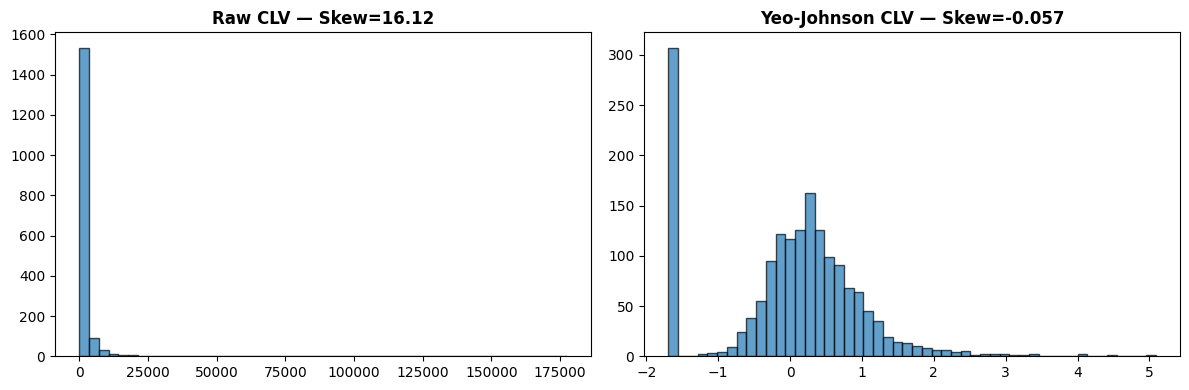

In [ ]:
# ============================================================
# TARGET TRANSFORM
# ============================================================

yj_target = PowerTransformer(method='yeo-johnson')
y_yj = yj_target.fit_transform(y_raw.values.reshape(-1, 1)).ravel()

print(f"Raw target skewness:       {skew(y_raw):.3f}")
print(f"Yeo-Johnson target skewness: {skew(y_yj):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_raw, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Raw CLV — Skew={skew(y_raw):.2f}', fontweight='bold')

axes[1].hist(y_yj, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title(f'Yeo-Johnson CLV — Skew={skew(y_yj):.3f}', fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# STRATIFICATION LABELS
# ============================================================

def make_clv_tier(series):
    nonzero = series[series > 0]
    p33 = nonzero.quantile(0.33)
    p67 = nonzero.quantile(0.67)

    return pd.cut(
        series,
        bins=[-1, 0, p33, p67, float('inf')],
        labels=['Zero', 'Low', 'Mid', 'High']
    )

stratify_labels = make_clv_tier(y_raw)

print("Tier distribution before split:")
print(stratify_labels.value_counts().sort_index())

Tier distribution before split:
clv_target
Zero    307
Low     457
Mid     471
High    457
Name: count, dtype: int64


In [ ]:
# ============================================================
# ONE SHARED SPLIT FOR ALL DATASETS
# ============================================================

idx = pd.Series(clv_df.index, index=clv_df.index)

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=stratify_labels
)

X_churn_train = X_churn.loc[train_idx]
X_churn_test  = X_churn.loc[test_idx]

X_train = X_clv.loc[train_idx]
X_test  = X_clv.loc[test_idx]

y_train_raw = y_raw.loc[train_idx]
y_test_raw  = y_raw.loc[test_idx]

y_train_yj = pd.Series(y_yj, index=clv_df.index).loc[train_idx].values
y_test_yj  = pd.Series(y_yj, index=clv_df.index).loc[test_idx].values

assert (X_churn_test.index == X_test.index).all(), "Index mismatch — splits are not aligned"

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print("X_churn_test and X_test indices aligned: ✓")
print("\nTest tier distribution:")
print(make_clv_tier(y_test_raw).value_counts().sort_index())

Train: 1353 | Test: 339
X_churn_test and X_test indices aligned: ✓

Test tier distribution:
clv_target
Zero    61
Low     92
Mid     94
High    92
Name: count, dtype: int64


In [ ]:
# ============================================================
# TWO-MODEL SETUP — CUTOFF AND MASKS
# ============================================================

WHALE_CUTOFF = clv_df.loc[train_idx, 'monetary'].quantile(0.80)
print(f"Whale cutoff (train monetary p80): £{WHALE_CUTOFF:,.2f}")

# Train masks
train_monetary      = clv_df.loc[train_idx, 'monetary']
whale_train_mask    = (train_monetary >= WHALE_CUTOFF).values
nonwhale_train_mask = ~whale_train_mask

# Test masks
test_monetary      = clv_df.loc[test_idx, 'monetary']
whale_test_mask    = (test_monetary >= WHALE_CUTOFF).values
nonwhale_test_mask = ~whale_test_mask

# Non-whale training data
X_train_nonwhale = X_train[nonwhale_train_mask]
y_train_nonwhale = y_train_raw.values[nonwhale_train_mask]

print(f"\nTrain: whale={whale_train_mask.sum()} | non-whale={nonwhale_train_mask.sum()}")
print(f"Test:  whale={whale_test_mask.sum()} | non-whale={nonwhale_test_mask.sum()}")
print(f"Non-whale CLV range: £{y_train_nonwhale.min():,.0f} — £{y_train_nonwhale.max():,.0f}")
print(f"Non-whale CLV mean:  £{y_train_nonwhale.mean():,.0f}")

Whale cutoff (train monetary p80): £2,170.62

Train: whale=271 | non-whale=1082
Test:  whale=75 | non-whale=264
Non-whale CLV range: £0 — £38,629
Non-whale CLV mean:  £790


In [ ]:
# ============================================================
# PREPROCESSING PIPELINES
# ============================================================

preprocessor_clv = ColumnTransformer(
    transformers=[
        ('yeojohnson', PowerTransformer(method='yeo-johnson', standardize=True), skewed_features_clv),
        ('passthrough', 'passthrough', passthrough_features_clv)
    ],
    remainder='drop'
)

pipeline_linear = Pipeline(steps=[
    ('preprocessor', preprocessor_clv),
    ('scaler', StandardScaler()),
    ('model', 'passthrough')
])

clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_clv),
    ('scaler', StandardScaler()),
    ('clf', 'passthrough')
])

pipeline_tree = Pipeline(steps=[
    ('preprocessor', preprocessor_clv),
    ('model', 'passthrough')
])

print("\nLinear pipeline steps:", [s[0] for s in pipeline_linear.steps])
print("Tree pipeline steps:  ", [s[0] for s in pipeline_tree.steps])


Linear pipeline steps: ['preprocessor', 'scaler', 'model']
Tree pipeline steps:   ['preprocessor', 'model']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Business Metric Function
def business_evaluation_clv(
    model_name,
    y_test,
    y_pred_clv,
    X_test,
    cost_per_contact=10,
    high_value_quantile=0.80,
    retention_rates={
        'Conservative (20%)': 0.20,
        'Moderate (35%)': 0.35,
        'Optimistic (50%)': 0.50
    }
):
    """
    Business metrics for CLV regression.

    Parameters:
    -----------
    model_name          : str
    y_test              : actual CLV (raw) - pandas Series aligned with X_test
    y_pred_clv          : predicted CLV (raw scale) - array or Series
    X_test              : raw CLV test feature matrix (must include 'monetary')
    cost_per_contact    : £ cost to reach one customer
    high_value_quantile : e.g. 0.80 = top 20%
    retention_rates     : dict of assumed lift/revenue retention from intervention
    """

    if 'monetary' not in X_test.columns:
        raise ValueError("X_test must contain the raw 'monetary' column for tier analysis.")

    # Build evaluation dataframe with index alignment
    results = X_test.copy()

    if isinstance(y_test, pd.Series):
        results['actual_clv'] = y_test.reindex(results.index)
    else:
        results['actual_clv'] = pd.Series(y_test, index=results.index)

    if isinstance(y_pred_clv, pd.Series):
        results['predicted_clv'] = y_pred_clv.reindex(results.index)
    else:
        results['predicted_clv'] = pd.Series(y_pred_clv, index=results.index)

    # Raw past spend from CLV X only
    results['past_monetary'] = results['monetary']

    # --- Define high-value based on actual CLV (top X%) ---
    n_customers = len(results)
    top_k = max(1, int(np.ceil((1 - high_value_quantile) * n_customers)))

    results['actual_rank'] = results['actual_clv'].rank(method='first', ascending=False)
    results['actual_high_value'] = (results['actual_rank'] <= top_k).astype(int)

    actual_hv = results.loc[results['actual_high_value'] == 1, 'actual_clv']
    actual_threshold = actual_hv.min() if not actual_hv.empty else np.nan

    # --- Define predicted high-value (top X% by predicted CLV) ---
    results['predicted_rank'] = results['predicted_clv'].rank(method='first', ascending=False)
    results['predicted_high_value'] = (results['predicted_rank'] <= top_k).astype(int)

    pred_hv = results.loc[results['predicted_high_value'] == 1, 'predicted_clv']
    pred_threshold = pred_hv.min() if not pred_hv.empty else np.nan

    # --- Revenue Capture ---
    total_high_value_revenue = results.loc[results['actual_high_value'] == 1, 'actual_clv'].sum()
    caught_revenue = results.loc[
        (results['actual_high_value'] == 1) & (results['predicted_high_value'] == 1),
        'actual_clv'
    ].sum()
    missed_revenue = results.loc[
        (results['actual_high_value'] == 1) & (results['predicted_high_value'] == 0),
        'actual_clv'
    ].sum()
    revenue_capture = caught_revenue / total_high_value_revenue if total_high_value_revenue > 0 else 0

    # --- Pareto Capture (Top 20% past spenders) ---
    p80_past = results['past_monetary'].quantile(0.80)
    top_past_customers = results[results['past_monetary'] >= p80_past]
    top_past_high_value = top_past_customers[top_past_customers['actual_high_value'] == 1]
    caught_top_past = top_past_high_value[top_past_high_value['predicted_high_value'] == 1]
    pareto_capture = len(caught_top_past) / len(top_past_high_value) if len(top_past_high_value) > 0 else 0

    # --- Expected Revenue Saved (ERS) ---
    ers = {label: caught_revenue * rate for label, rate in retention_rates.items()}

    # --- Intervention Cost Efficiency ---
    total_flagged = (results['predicted_high_value'] == 1).sum()
    true_positives = ((results['predicted_high_value'] == 1) &
                      (results['actual_high_value'] == 1)).sum()
    false_positives = ((results['predicted_high_value'] == 1) &
                       (results['actual_high_value'] == 0)).sum()

    total_spend = total_flagged * cost_per_contact
    useful_spend = true_positives * cost_per_contact
    wasted_spend = false_positives * cost_per_contact
    cost_efficiency = useful_spend / total_spend if total_spend > 0 else 0

    # --- Revenue at Risk Coverage by Tier (based on past monetary) ---
    q20 = results['past_monetary'].quantile(0.20)
    q80 = results['past_monetary'].quantile(0.80)

    tier_stats = []
    tier_defs = [
        ('Tier 1 — Top 20% past', results['past_monetary'] >= q80),
        ('Tier 2 — Mid 60% past', (results['past_monetary'] >= q20) & (results['past_monetary'] < q80)),
        ('Tier 3 — Bottom 20% past', results['past_monetary'] < q20),
    ]

    for tier_name, mask in tier_defs:
        tier = results[mask]
        tier_hv = tier[tier['actual_high_value'] == 1]
        tier_caught = tier_hv[tier_hv['predicted_high_value'] == 1]

        tier_rev_total = tier_hv['actual_clv'].sum()
        tier_rev_caught = tier_caught['actual_clv'].sum()
        tier_capture = tier_rev_caught / tier_rev_total if tier_rev_total > 0 else 0

        tier_stats.append({
            'tier': tier_name,
            'high_value_customers': len(tier_hv),
            'caught': len(tier_caught),
            'revenue_at_risk': tier_rev_total,
            'revenue_caught': tier_rev_caught,
            'capture_rate': tier_capture
        })

    tier_df = pd.DataFrame(tier_stats)

    # --- Print Summary ---
    print("=" * 70)
    print(f"BUSINESS METRICS FOR CLV — {model_name}")
    print("=" * 70)
    print(f"\nTargeting top {int((1 - high_value_quantile) * 100)}% of predicted CLV (exact count)")
    print(f"Actual high-value threshold: £{actual_threshold:,.2f}")
    print(f"Predicted threshold: £{pred_threshold:,.2f}")

    print(f"\n── Revenue Capture ───────────────────────────────────────")
    print(f"   Total high-value future revenue:  £{total_high_value_revenue:,.0f}")
    print(f"   Captured by targeting:            £{caught_revenue:,.0f}  ({revenue_capture:.2%})")
    print(f"   Missed:                           £{missed_revenue:,.0f}  ({1 - revenue_capture:.2%})")

    print(f"\n── Pareto Capture (Top 20% past spenders) ────────────────")
    print(f"   High-value among past top spenders: {len(top_past_high_value)}")
    print(f"   Caught by model:                    {len(caught_top_past)}  ({pareto_capture:.2%})")

    print(f"\n── Expected Revenue Saved (ERS) ──────────────────────────")
    print(f"   Based on £{caught_revenue:,.0f} of captured future revenue:")
    for label, value in ers.items():
        print(f"   {label:<25} £{value:,.0f}")

    print(f"\n── Intervention Cost Efficiency ──────────────────────────")
    print(f"   Cost per contact:          £{cost_per_contact}")
    print(f"   Customers flagged:         {total_flagged}")
    print(f"   True high-value flagged:    {true_positives}  (useful spend)")
    print(f"   False positives:            {false_positives}  (wasted spend)")
    print(f"   Total spend:                £{total_spend:,.0f}")
    print(f"   Useful spend:               £{useful_spend:,.0f}  ({cost_efficiency:.2%} efficiency)")
    print(f"   Wasted spend:               £{wasted_spend:,.0f}  ({1 - cost_efficiency:.2%} waste)")

    print(f"\n── Revenue at Risk by Past Spend Tier ────────────────────")
    for _, row in tier_df.iterrows():
        print(f"   {row['tier']}")
        print(f"     High-value customers: {int(row['high_value_customers'])}  |  "
              f"Revenue at risk: £{row['revenue_at_risk']:,.0f}  |  "
              f"Capture rate: {row['capture_rate']:.2%}")

    # --- Lift Curves ---
    results_sorted = results.sort_values('predicted_clv', ascending=False).reset_index(drop=True)
    n = len(results_sorted)

    total_hv_revenue = results_sorted.loc[results_sorted['actual_high_value'] == 1, 'actual_clv'].sum()
    results_sorted['hv_clv'] = results_sorted['actual_clv'] * results_sorted['actual_high_value']
    results_sorted['cum_hv_clv'] = results_sorted['hv_clv'].cumsum()
    results_sorted['revenue_capture_rate'] = (
        results_sorted['cum_hv_clv'] / total_hv_revenue if total_hv_revenue > 0 else 0
    )

    total_hv_customers = results_sorted['actual_high_value'].sum()
    results_sorted['cum_hv_customers'] = results_sorted['actual_high_value'].cumsum()
    results_sorted['hv_capture_rate'] = (
        results_sorted['cum_hv_customers'] / total_hv_customers if total_hv_customers > 0 else 0
    )

    results_sorted['cum_customers_pct'] = (results_sorted.index + 1) / n

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cutoff_n = max(1, int(np.ceil(0.2 * n)))
    cutoff_idx = cutoff_n - 1

    # Revenue Lift
    rev_at_20 = results_sorted['revenue_capture_rate'].iloc[cutoff_idx]
    axes[0].plot(results_sorted['cum_customers_pct'], results_sorted['revenue_capture_rate'],
                 linewidth=2, label='Model')
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
    axes[0].axvline(x=0.2, linestyle=':', linewidth=1.2, label='Top 20%')
    axes[0].annotate(f'{rev_at_20:.0%} of future revenue\ncaptured in top 20%',
                     xy=(0.2, rev_at_20),
                     xytext=(0.35, max(0, rev_at_20 - 0.1)),
                     arrowprops=dict(arrowstyle='->'),
                     fontsize=9)
    axes[0].set_xlabel('Fraction of Customers Targeted')
    axes[0].set_ylabel('Fraction of Future Revenue Captured')
    axes[0].set_title(f'Revenue Lift Curve — {model_name}', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # High-Value Customer Capture
    hv_at_20 = results_sorted['hv_capture_rate'].iloc[cutoff_idx]
    axes[1].plot(results_sorted['cum_customers_pct'], results_sorted['hv_capture_rate'],
                 linewidth=2, label='Model')
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
    axes[1].axvline(x=0.2, linestyle=':', linewidth=1.2, label='Top 20%')
    axes[1].annotate(f'{hv_at_20:.0%} of high-value customers\ncaptured in top 20%',
                     xy=(0.2, hv_at_20),
                     xytext=(0.35, max(0, hv_at_20 - 0.1)),
                     arrowprops=dict(arrowstyle='->'),
                     fontsize=9)
    axes[1].set_xlabel('Fraction of Customers Targeted')
    axes[1].set_ylabel('Fraction of High-Value Customers Captured')
    axes[1].set_title(f'High-Value Customer Lift — {model_name}', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'revenue_capture': revenue_capture,
        'pareto_capture': pareto_capture,
        'rev_lift_at_20pct': rev_at_20,
        'hv_lift_at_20pct': hv_at_20,
        'ers_conservative': ers['Conservative (20%)'],
        'ers_moderate': ers['Moderate (35%)'],
        'ers_optimistic': ers['Optimistic (50%)'],
        'total_spend': total_spend,
        'wasted_spend': wasted_spend,
        'cost_efficiency': cost_efficiency,
        'tier_coverage': tier_df
    }

In [ ]:
# Comparison table for models
def build_comparison_table_regression(results_dict):
    """
    results_dict: {model_name: dict_of_metrics}
    Expected keys: 'MAE', 'RMSE', 'R2_YJ', 'MAPE_pos', 'Zero_Accuracy',
                   'Revenue_Capture', 'Pareto_Capture', 'ERS_Moderate',
                   'Cost_Efficiency', 'Wasted_Spend', 'ROI' (optional)
    """
    df_comp = pd.DataFrame(results_dict).T
    df_comp.index.name = 'Model'
    df_comp = df_comp.reset_index()

    col_order = [
        'Model',
        # Statistical
        'MAE', 'RMSE', 'R2_YJ', 'MAPE_pos', 'Zero_Accuracy',
        # Business
        'Revenue_Capture', 'Pareto_Capture', 'ERS_Moderate',
        'Cost_Efficiency', 'Wasted_Spend', 'ROI'
    ]
    col_order = [c for c in col_order if c in df_comp.columns]
    df_comp = df_comp[col_order]

    def highlight_best(col):
        styles = [''] * len(col)
        if col.name == 'Model':
            return styles
        # For Wasted_Spend, lower is better; for others (except ROI) higher is better
        lower_is_better = ['Wasted_Spend', 'MAE', 'RMSE', 'MAPE_pos']
        numeric_vals = {}
        for i, val in enumerate(col):
            try:
                numeric_vals[i] = float(str(val).replace('%', '').replace('£', '').replace(',', ''))
            except:
                pass
        if len(numeric_vals) < 2:
            return styles
        if col.name in lower_is_better:
            best_idx = min(numeric_vals, key=numeric_vals.get)
        else:
            best_idx = max(numeric_vals, key=numeric_vals.get)
        worst_idx = max(numeric_vals, key=numeric_vals.get) if col.name in lower_is_better else min(numeric_vals, key=numeric_vals.get)
        if best_idx != worst_idx:
            styles[best_idx] = 'background-color: #d4edda; color: #155724; font-weight: bold'
            styles[worst_idx] = 'background-color: #f8d7da; color: #721c24'
        return styles

    return (df_comp.style
            .apply(highlight_best, axis=0)
            .set_properties(**{'text-align': 'center', 'font-size': '12px', 'padding': '8px 12px'})
            .set_table_styles([{
                'selector': 'th',
                'props': [('background-color', '#2c3e50'), ('color', 'white'),
                          ('font-size', '12px'), ('text-align', 'center'), ('padding', '10px 12px')]
            }])
            .hide(axis='index'))

# Modeling


Constant Predictors

In [ ]:
# Mean predictor
y_pred_mean = np.full(len(y_test_raw), y_train_raw.mean())
# Median predictor
y_pred_median = np.full(len(y_test_raw), y_train_raw.median())

print("=== CONSTANT PREDICTORS (RAW CLV) ===")
print(f"Mean predictor - MAE: {mean_absolute_error(y_test_raw, y_pred_mean):.2f}, RMSE: {np.sqrt(mean_squared_error(y_test_raw, y_pred_mean)):.2f}")
print(f"Median predictor - MAE: {mean_absolute_error(y_test_raw, y_pred_median):.2f}, RMSE: {np.sqrt(mean_squared_error(y_test_raw, y_pred_median)):.2f}")

=== CONSTANT PREDICTORS (RAW CLV) ===
Mean predictor - MAE: 2197.35, RMSE: 7698.00
Median predictor - MAE: 1886.35, RMSE: 7823.84


In [ ]:
# ============================================================
# EXTRACT CONSTANT MODEL METRICS (NO REFACTORING)
# ============================================================

mae_mean  = mean_absolute_error(y_test_raw, y_pred_mean)
rmse_mean = np.sqrt(mean_squared_error(y_test_raw, y_pred_mean))

mae_med   = mean_absolute_error(y_test_raw, y_pred_median)
rmse_med  = np.sqrt(mean_squared_error(y_test_raw, y_pred_median))

**Model 1: Two Stage Model**

Stage 1: Churn model (general and high value)

Stage 2: Linear regression


In [ ]:
# ============================================================
# STEP 0 — MOUNT GOOGLE DRIVE AND LOAD CHURN MODELS
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import joblib
import os

# Path to the folder where you saved the models
DRIVE_PATH = '/content/drive/MyDrive/churn_models/'

# Correct filenames (as saved)
general_model_path   = os.path.join(DRIVE_PATH, 'churn_model_general.pkl')
highvalue_model_path = os.path.join(DRIVE_PATH, 'churn_model_highvalue.pkl')

# Check existence
general_model_exists   = os.path.exists(general_model_path)
highvalue_model_exists = os.path.exists(highvalue_model_path)

print(f"General churn model found:    {general_model_exists}")
print(f"High-value churn model found: {highvalue_model_exists}")

# Load models
if general_model_exists:
    churn_model_general = joblib.load(general_model_path)
    print("General churn model loaded.")
else:
    print("WARNING: General churn model not found. Check path and filename.")

if highvalue_model_exists:
    churn_model_hv = joblib.load(highvalue_model_path)
    print("High-value churn model loaded.")
else:
    print("WARNING: High-value churn model not found.")

Mounted at /content/drive
General churn model found:    True
High-value churn model found: True
General churn model loaded.
High-value churn model loaded.


In [ ]:
# ============================================================
# STAGE 1 — CHURN MODEL GATE
# X_churn_test (16 features) feeds the churn models
# Output: binary array — 1 = predicted to spend, 0 = predicted churned
# ============================================================

GENERAL_THRESHOLD    = 0.50
HIGHVALUE_THRESHOLD  = 0.25
HIGHVALUE_SPEND_CUTOFF = 2199   # top 20% past spenders from churn project

def get_stage1_predictions(X_churn_input, df_full,
                           general_model=None, hv_model=None,
                           general_threshold=0.50,
                           hv_threshold=0.25,
                           hv_spend_cutoff=2199):
    """
    Parameters
    ----------
    X_churn_input : DataFrame with 16 churn features — fed to churn models only
    df_full       : original clv_df — used to pull past monetary for HV split
    """
    n           = len(X_churn_input)
    predictions = np.ones(n, dtype=int)   # default: everyone spends

    past_monetary = df_full.loc[X_churn_input.index, 'monetary']
    is_highvalue  = (past_monetary >= hv_spend_cutoff).values

    # General model — covers all customers
    if general_model is not None:
        probs        = general_model.predict_proba(X_churn_input)[:, 1]  # P(churn)
        flags        = (probs > general_threshold).astype(int)
        predictions  = np.where(flags == 1, 0, 1)   # churned → CLV = 0

    # High-value override — stricter threshold for whale customers
    if hv_model is not None and is_highvalue.sum() > 0:
        X_hv       = X_churn_input[is_highvalue]
        hv_probs   = hv_model.predict_proba(X_hv)[:, 1]
        hv_flags   = (hv_probs > hv_threshold).astype(int)
        hv_idx     = np.where(is_highvalue)[0]
        predictions[hv_idx] = np.where(hv_flags == 1, 0, 1)
        print(f"  HV override applied to {is_highvalue.sum()} customers at threshold {hv_threshold}")

    return predictions


print("=== STAGE 1 — Churn Model Gate ===")

y_pred_binary = get_stage1_predictions(
    X_churn_input   = X_churn_test,       # 16 features → churn models
    df_full         = clv_df,
    general_model   = churn_model_general,
    hv_model        = churn_model_hv,
    general_threshold  = GENERAL_THRESHOLD,
    hv_threshold       = HIGHVALUE_THRESHOLD,
    hv_spend_cutoff    = HIGHVALUE_SPEND_CUTOFF
)

y_test_binary = (y_test_raw > 0).astype(int)

print(f"\nPredicted zeros:   {(y_pred_binary == 0).sum():<4}  |  Actual zeros:    {(y_test_binary == 0).sum()}")
print(f"Predicted nonzero: {(y_pred_binary == 1).sum():<4}  |  Actual non-zero: {(y_test_binary == 1).sum()}")
print(f"Zero accuracy:     {(y_pred_binary == y_test_binary.values).mean():.3f}")
print(f"Zeros correctly caught: "
      f"{((y_pred_binary == 0) & (y_test_binary.values == 0)).sum()} "
      f"/ {(y_test_binary == 0).sum()}")

=== STAGE 1 — Churn Model Gate ===
  HV override applied to 73 customers at threshold 0.25

Predicted zeros:   193   |  Actual zeros:    61
Predicted nonzero: 146   |  Actual non-zero: 278
Zero accuracy:     0.534
Zeros correctly caught: 48 / 61


In [ ]:
# ============================================================
# STAGE 2 — LINEAR REGRESSION ON NON-ZERO CLV CUSTOMERS
# X_train / X_test (15 CLV features) feeds the regression pipeline
# Trained ONLY on customers with positive CLV in training set
# ============================================================

from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Train on non-zero CLV customers only
mask_train_nz  = (y_train_raw > 0).values
X_train_nz     = X_train[mask_train_nz]          # 15 CLV features
y_train_yj_nz  = y_train_yj[mask_train_nz]

stage2_pipeline = clone(pipeline_linear)
stage2_pipeline.set_params(model=LinearRegression())
stage2_pipeline.fit(X_train_nz, y_train_yj_nz)

print(f"Stage 2 trained on {mask_train_nz.sum()} non-zero CLV customers")

# Predict on ALL test customers in YJ space, then invert to pounds
y_pred_yj_all  = stage2_pipeline.predict(X_test)     # 15 CLV features
y_pred_raw_all = yj_target.inverse_transform(
                     y_pred_yj_all.reshape(-1, 1)
                 ).ravel()
y_pred_raw_all = np.clip(y_pred_raw_all, 0, None)    # no negative CLV

# Apply Stage 1 gate — churned customers get CLV = 0
y_pred_final  = np.where(y_pred_binary == 0, 0.0, y_pred_raw_all)
y_pred_series = pd.Series(y_pred_final, index=X_test.index)

Stage 2 trained on 1107 non-zero CLV customers


=== STATISTICAL METRICS — Two-Stage Baseline (Churn Gate + Linear Regression) ===
MAE:            £1,598.84
RMSE:           £6,408.97
R² (YJ space):  -0.8315
MAPE (pos):     105.0%
Zero accuracy:  0.534
BUSINESS METRICS FOR CLV — Two-Stage Baseline (Churn + LinReg)

Targeting top 19% of predicted CLV (exact count)
Actual high-value threshold: £2,026.46
Predicted threshold: £1,438.43

── Revenue Capture ───────────────────────────────────────
   Total high-value future revenue:  £553,906
   Captured by targeting:            £408,316  (73.72%)
   Missed:                           £145,590  (26.28%)

── Pareto Capture (Top 20% past spenders) ────────────────
   High-value among past top spenders: 43
   Caught by model:                    28  (65.12%)

── Expected Revenue Saved (ERS) ──────────────────────────
   Based on £408,316 of captured future revenue:
   Conservative (20%)        £81,663
   Moderate (35%)            £142,911
   Optimistic (50%)          £204,158

── Intervention Cos

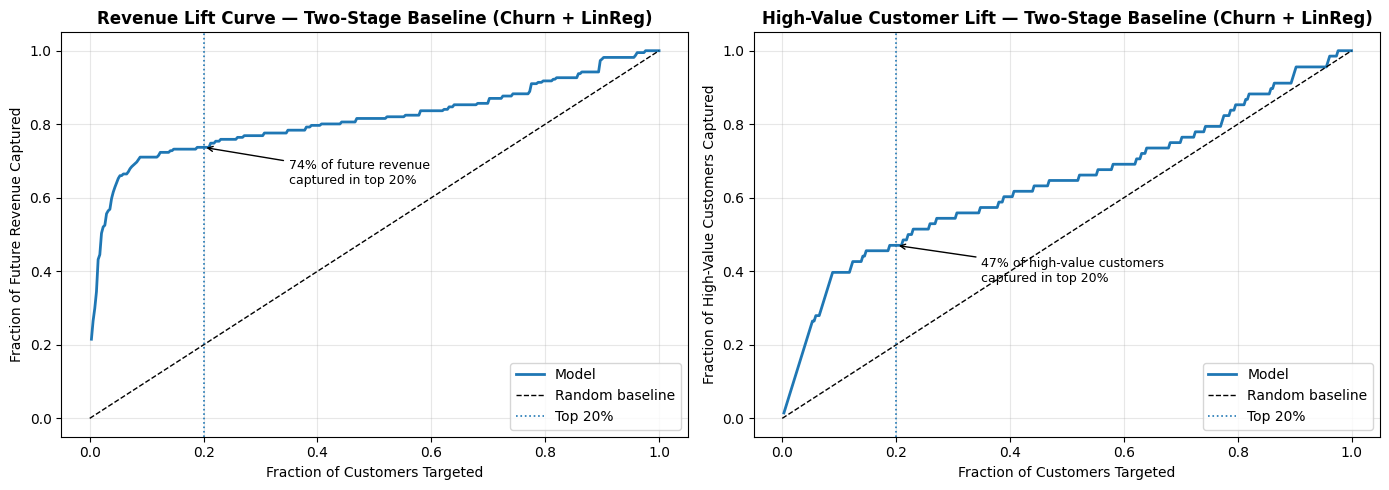

Model,MAE,RMSE,R2_YJ,MAPE_pos,Zero_Accuracy,Revenue_Capture,Pareto_Capture,ERS_Moderate,Cost_Efficiency,Wasted_Spend,ROI
Mean Predictor,"£2,197","£7,698",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
Median Predictor,"£1,886","£7,824",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
Two-Stage Baseline (Churn + LinReg),"£1,599","£6,409",-0.832,105.0%,53.39%,73.7%,65.1%,"£142,911",47.1%,£360,20916.3%


In [ ]:
# ============================================================
# STATISTICAL METRICS
# ============================================================
mae  = mean_absolute_error(y_test_raw, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred_final))

y_pred_yj_final = yj_target.transform(y_pred_final.reshape(-1, 1)).ravel()
r2_yj           = r2_score(y_test_yj, y_pred_yj_final)

mask_pos = (y_test_raw > 0).values
mape_pos = (np.abs((y_test_raw.values[mask_pos] - y_pred_final[mask_pos])
                   / y_test_raw.values[mask_pos]).mean()) * 100

zero_acc = (y_pred_binary == y_test_binary.values).mean()

print("=== STATISTICAL METRICS — Two-Stage Baseline (Churn Gate + Linear Regression) ===")
print(f"MAE:            £{mae:,.2f}")
print(f"RMSE:           £{rmse:,.2f}")
print(f"R² (YJ space):  {r2_yj:.4f}")
print(f"MAPE (pos):     {mape_pos:.1f}%")
print(f"Zero accuracy:  {zero_acc:.3f}")

# ============================================================
# BUSINESS METRICS (using the provided function)
# ============================================================
model_name = "Two-Stage Baseline (Churn + LinReg)"
business_metrics = business_evaluation_clv(
    model_name=model_name,
    y_test=y_test_raw,            # actual CLV (raw)
    y_pred_clv=y_pred_series,     # predicted CLV (raw)
    X_test=X_test,                # must contain 'monetary' column
    cost_per_contact=10,
    high_value_quantile=0.80,
    retention_rates={
        'Conservative (20%)': 0.20,
        'Moderate (35%)': 0.35,
        'Optimistic (50%)': 0.50
    }
)

# Extract business metrics for comparison table
revenue_capture = business_metrics['revenue_capture']
pareto_capture  = business_metrics['pareto_capture']
rev_lift_at_20  = business_metrics['rev_lift_at_20pct']
hv_lift_at_20   = business_metrics['hv_lift_at_20pct']
ers_moderate    = business_metrics['ers_moderate']
total_spend     = business_metrics['total_spend']
wasted_spend    = business_metrics['wasted_spend']
cost_efficiency = business_metrics['cost_efficiency']

# Optional: Compute ROI (based on moderate retention scenario)
ers_moderate_val = business_metrics['ers_moderate']
roi = (ers_moderate_val - total_spend) / total_spend if total_spend > 0 else 0

# ============================================================
# BUILD COMPARISON TABLE (includes both statistical & business)
# ============================================================
results_dict = {

    # --------------------------------------------------------
    # CONSTANT BASELINES (ADD THESE)
    # --------------------------------------------------------
    "Mean Predictor": {
        'MAE': f"£{mae_mean:,.0f}",
        'RMSE': f"£{rmse_mean:,.0f}",
        'R2_YJ': "N/A",
        'MAPE_pos': "N/A",
        'Zero_Accuracy': "N/A",
        'Revenue_Capture': "N/A",
        'Pareto_Capture': "N/A",
        'ERS_Moderate': "N/A",
        'Cost_Efficiency': "N/A",
        'Wasted_Spend': "N/A",
        'ROI': "N/A"
    },

    "Median Predictor": {
        'MAE': f"£{mae_med:,.0f}",
        'RMSE': f"£{rmse_med:,.0f}",
        'R2_YJ': "N/A",
        'MAPE_pos': "N/A",
        'Zero_Accuracy': "N/A",
        'Revenue_Capture': "N/A",
        'Pareto_Capture': "N/A",
        'ERS_Moderate': "N/A",
        'Cost_Efficiency': "N/A",
        'Wasted_Spend': "N/A",
        'ROI': "N/A"
    },

    # --------------------------------------------------------
    # YOUR EXISTING MODEL (UNCHANGED)
    # --------------------------------------------------------
    model_name: {
        'MAE': f"£{mae:,.0f}",
        'RMSE': f"£{rmse:,.0f}",
        'R2_YJ': f"{r2_yj:.3f}",
        'MAPE_pos': f"{mape_pos:.1f}%",
        'Zero_Accuracy': f"{zero_acc:.2%}",
        'Revenue_Capture': f"{revenue_capture:.1%}",
        'Pareto_Capture': f"{pareto_capture:.1%}",
        'ERS_Moderate': f"£{ers_moderate:,.0f}",
        'Cost_Efficiency': f"{cost_efficiency:.1%}",
        'Wasted_Spend': f"£{wasted_spend:,.0f}",
        'ROI': f"{roi:.1%}"
    }
}


# Display the styled comparison table
comparison_table = build_comparison_table_regression(results_dict)
comparison_table

In [ ]:
# Try these thresholds for Stage 1 and compare zeros caught vs false positives
for threshold in [0.55, 0.60, 0.65, 0.70, 0.75]:
    probs = churn_model_general.predict_proba(X_churn_test)[:, 1]
    flags = (probs > threshold).astype(int)
    predicted_zeros = (flags == 1).sum()
    actual_zeros_caught = ((flags == 1) & (y_test_binary.values == 0)).sum()
    false_positives = ((flags == 1) & (y_test_binary.values == 1)).sum()
    print(f"Threshold {threshold:.2f} → predicted zeros: {predicted_zeros:3d} | "
          f"correct: {actual_zeros_caught:2d}/61 | false positives: {false_positives}")

Threshold 0.55 → predicted zeros: 134 | correct: 38/61 | false positives: 96
Threshold 0.60 → predicted zeros: 113 | correct: 35/61 | false positives: 78
Threshold 0.65 → predicted zeros:  88 | correct: 28/61 | false positives: 60
Threshold 0.70 → predicted zeros:  63 | correct: 19/61 | false positives: 44
Threshold 0.75 → predicted zeros:  42 | correct: 13/61 | false positives: 29


Model 2: Random forest


In [ ]:
# ── Train Random Forest (raw CLV) ─────────────────────────
rf_pipeline = clone(pipeline_tree)
rf_pipeline.set_params(model=RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
))
rf_pipeline.fit(X_train, y_train_raw)
y_pred_rf = np.clip(rf_pipeline.predict(X_test), 0, None)

In [ ]:
# ── Statistical metrics ───────────────────────────────────
mae_rf  = mean_absolute_error(y_test_raw, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_raw, y_pred_rf))
r2_rf   = r2_score(y_test_raw, y_pred_rf)

mask_pos = y_test_raw > 0
mape_rf = np.mean(np.abs(
    (y_test_raw[mask_pos] - y_pred_rf[mask_pos]) / y_test_raw[mask_pos]
)) * 100

print("=" * 60)
print("Random Forest — STATISTICAL METRICS")
print("=" * 60)
print(f"MAE  : £{mae_rf:,.2f}")
print(f"RMSE : £{rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")
print(f"MAPE : {mape_rf:.2f}%")

Random Forest — STATISTICAL METRICS
MAE  : £1,421.58
RMSE : £4,605.71
R²   : 0.6412
MAPE : 136.28%


BUSINESS METRICS FOR CLV — Random Forest (Single Stage CLV)

Targeting top 19% of predicted CLV (exact count)
Actual high-value threshold: £2,026.46
Predicted threshold: £2,028.94

── Revenue Capture ───────────────────────────────────────
   Total high-value future revenue:  £553,906
   Captured by targeting:            £456,766  (82.46%)
   Missed:                           £97,141  (17.54%)

── Pareto Capture (Top 20% past spenders) ────────────────
   High-value among past top spenders: 43
   Caught by model:                    37  (86.05%)

── Expected Revenue Saved (ERS) ──────────────────────────
   Based on £456,766 of captured future revenue:
   Conservative (20%)        £91,353
   Moderate (35%)            £159,868
   Optimistic (50%)          £228,383

── Intervention Cost Efficiency ──────────────────────────
   Cost per contact:          £10
   Customers flagged:         68
   True high-value flagged:    39  (useful spend)
   False positives:            29  (wasted spend)


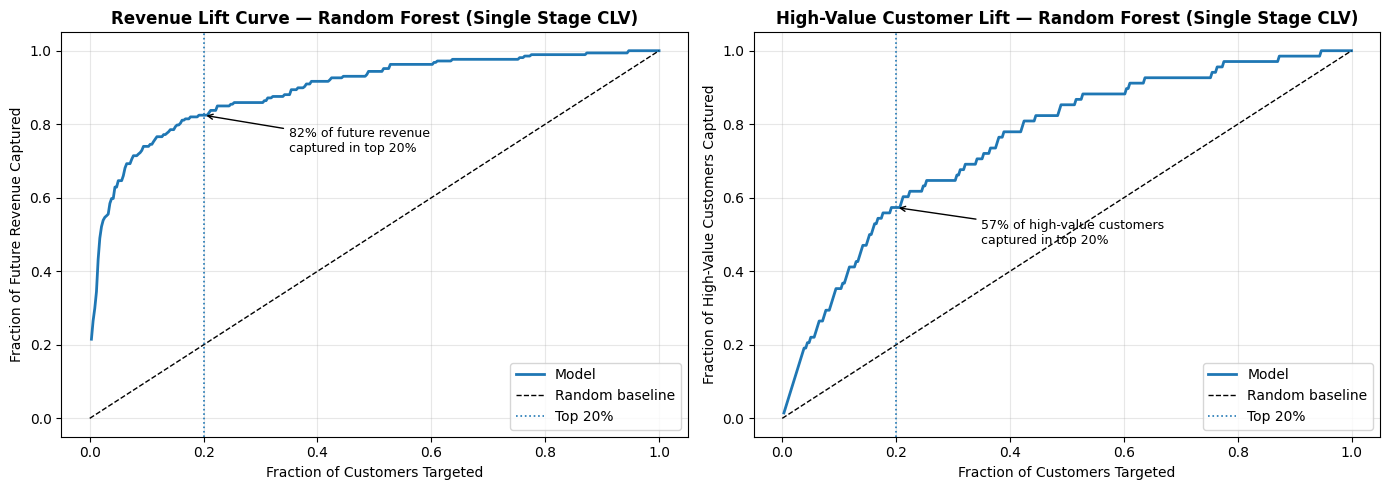

Model,MAE,RMSE,R2_YJ,MAPE_pos,Zero_Accuracy,Revenue_Capture,Pareto_Capture,ERS_Moderate,Cost_Efficiency,Wasted_Spend,ROI
Mean Predictor,"£2,197","£7,698",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
Median Predictor,"£1,886","£7,824",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
Two-Stage Baseline (Churn + LinReg),"£1,599","£6,409",-0.832,105.0%,53.39%,73.7%,65.1%,"£142,911",47.1%,£360,20916.3%
Random Forest,"£1,422","£4,606",0.641,136.3%,N/A,82.5%,86.0%,"£159,868",57.4%,£290,23410.0%


In [ ]:
# ── Business metrics (CLV evaluation) ─────────────────────
results_rf = business_evaluation_clv(
    model_name="Random Forest (Single Stage CLV)",
    y_test=y_test_raw,
    y_pred_clv=y_pred_rf,
    X_test=X_test,
    cost_per_contact=10,
    high_value_quantile=0.80
)

# ── Add Random Forest to the existing results_dict ────────
results_dict["Random Forest"] = {
    'MAE': f"£{mae_rf:,.0f}",
    'RMSE': f"£{rmse_rf:,.0f}",
    'R2_YJ': f"{r2_rf:.3f}",
    'MAPE_pos': f"{mape_rf:.1f}%",
    'Zero_Accuracy': "N/A",
    'Revenue_Capture': f"{results_rf['revenue_capture']:.1%}",
    'Pareto_Capture':  f"{results_rf['pareto_capture']:.1%}",
    'ERS_Moderate':    f"£{results_rf['ers_moderate']:,.0f}",
    'Cost_Efficiency': f"{results_rf['cost_efficiency']:.1%}",
    'Wasted_Spend':    f"£{results_rf['wasted_spend']:,.0f}",
    'ROI': f"{(results_rf['ers_moderate'] - results_rf['total_spend']) / results_rf['total_spend']:.1%}"
}

# ── Rebuild and display the updated comparison table ──────
comparison_table = build_comparison_table_regression(results_dict)
comparison_table

Model 2: XGBoost


In [ ]:
from xgboost import XGBRegressor

xgb_pipeline = clone(pipeline_tree)
xgb_pipeline.set_params(model=XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
))
xgb_pipeline.fit(X_train, y_train_raw)
y_pred_xgb = np.clip(xgb_pipeline.predict(X_test), 0, None)

In [ ]:
mae_xgb  = mean_absolute_error(y_test_raw, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_raw, y_pred_xgb))
r2_xgb   = r2_score(y_test_raw, y_pred_xgb)

mask_pos = y_test_raw > 0
mape_xgb = np.mean(np.abs(
    (y_test_raw[mask_pos] - y_pred_xgb[mask_pos]) / y_test_raw[mask_pos]
)) * 100

print("=" * 60)
print("XGBoost — STATISTICAL METRICS")
print("=" * 60)
print(f"MAE  : £{mae_xgb:,.2f}")
print(f"RMSE : £{rmse_xgb:,.2f}")
print(f"R²   : {r2_xgb:.4f}")
print(f"MAPE : {mape_xgb:.2f}%")

XGBoost — STATISTICAL METRICS
MAE  : £1,831.16
RMSE : £7,340.50
R²   : 0.0885
MAPE : 132.38%


BUSINESS METRICS FOR CLV — XGBoost (Single Stage CLV)

Targeting top 19% of predicted CLV (exact count)
Actual high-value threshold: £2,026.46
Predicted threshold: £1,923.86

── Revenue Capture ───────────────────────────────────────
   Total high-value future revenue:  £553,906
   Captured by targeting:            £458,388  (82.76%)
   Missed:                           £95,518  (17.24%)

── Pareto Capture (Top 20% past spenders) ────────────────
   High-value among past top spenders: 43
   Caught by model:                    38  (88.37%)

── Expected Revenue Saved (ERS) ──────────────────────────
   Based on £458,388 of captured future revenue:
   Conservative (20%)        £91,678
   Moderate (35%)            £160,436
   Optimistic (50%)          £229,194

── Intervention Cost Efficiency ──────────────────────────
   Cost per contact:          £10
   Customers flagged:         68
   True high-value flagged:    40  (useful spend)
   False positives:            28  (wasted spend)
   Tot

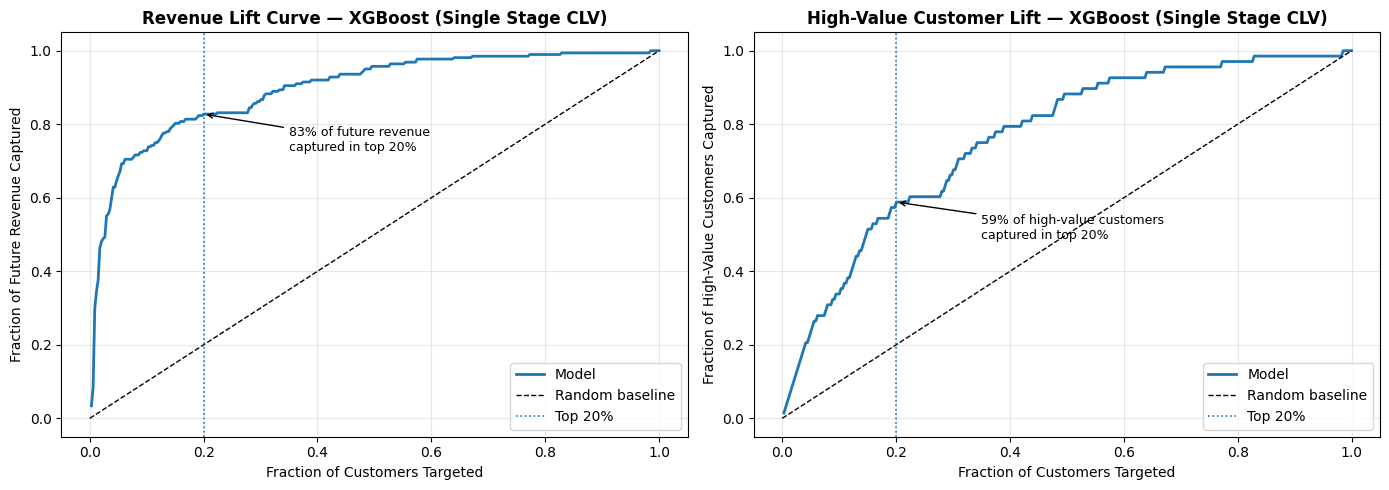

Model,MAE,RMSE,R2_YJ,MAPE_pos,Zero_Accuracy,Revenue_Capture,Pareto_Capture,ERS_Moderate,Cost_Efficiency,Wasted_Spend,ROI
Mean Predictor,"£2,197","£7,698",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
Median Predictor,"£1,886","£7,824",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
Two-Stage Baseline (Churn + LinReg),"£1,599","£6,409",-0.832,105.0%,53.39%,73.7%,65.1%,"£142,911",47.1%,£360,20916.3%
Random Forest,"£1,422","£4,606",0.641,136.3%,N/A,82.5%,86.0%,"£159,868",57.4%,£290,23410.0%
XGBoost,"£1,831","£7,340.50",0.089,132.4%,N/A,82.8%,88.4%,"£160,436",58.8%,£280,23493.5%


In [ ]:
results_xgb = business_evaluation_clv(
    model_name="XGBoost (Single Stage CLV)",
    y_test=y_test_raw,
    y_pred_clv=y_pred_xgb,
    X_test=X_test,
    cost_per_contact=10,
    high_value_quantile=0.80
)

# ── Pull RF metrics (already computed above) ──────────────
mae_rf   = mean_absolute_error(y_test_raw, y_pred_rf)
rmse_rf  = np.sqrt(mean_squared_error(y_test_raw, y_pred_rf))
r2_rf    = r2_score(y_test_raw, y_pred_rf)
mape_rf  = np.mean(np.abs(
    (y_test_raw[mask_pos] - y_pred_rf[mask_pos]) / y_test_raw[mask_pos]
)) * 100


# ── Add XGBoost to the existing results_dict (flat) ────────
results_dict["XGBoost"] = {
    'MAE': f"£{mae_xgb:,.0f}",
    'RMSE': f"£{rmse_xgb:,.2f}",
    'R2_YJ': f"{r2_xgb:.3f}",
    'MAPE_pos': f"{mape_xgb:.1f}%",
    'Zero_Accuracy': "N/A",
    'Revenue_Capture': f"{results_xgb['revenue_capture']:.1%}",
    'Pareto_Capture':  f"{results_xgb['pareto_capture']:.1%}",
    'ERS_Moderate':    f"£{results_xgb['ers_moderate']:,.0f}",
    'Cost_Efficiency': f"{results_xgb['cost_efficiency']:.1%}",
    'Wasted_Spend':    f"£{results_xgb['wasted_spend']:,.0f}",
    'ROI': f"{(results_xgb['ers_moderate'] - results_xgb['total_spend']) / results_xgb['total_spend']:.1%}"
}

# ── Rebuild and display the updated comparison table ──────
comparison_table = build_comparison_table_regression(results_dict)
comparison_table

XGBoost Optimized

In [ ]:
from sklearn.model_selection import GridSearchCV

# Focused grid – ~36 fits, very quick on 1.6k rows
param_grid_focused = {
    'model__max_depth':        [4, 5, 6],
    'model__n_estimators':     [300, 500],
    'model__learning_rate':    [0.01, 0.05],
    'model__min_child_weight': [1, 5, 10],
}

xgb_base = clone(pipeline_tree)
xgb_base.set_params(model=XGBRegressor(
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
))

grid_search = GridSearchCV(
    xgb_base,
    param_grid_focused,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train_raw)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV MAE: £{-grid_search.best_score_:,.2f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__min_child_weight': 5, 'model__n_estimators': 500}
Best CV MAE: £1,131.75


In [ ]:
# Predict with tuned model
y_pred_xgb_tuned = np.clip(grid_search.predict(X_test), 0, None)

# Statistical metrics
mae_xgb_tuned   = mean_absolute_error(y_test_raw, y_pred_xgb_tuned)
rmse_xgb_tuned  = np.sqrt(mean_squared_error(y_test_raw, y_pred_xgb_tuned))
r2_xgb_tuned    = r2_score(y_test_raw, y_pred_xgb_tuned)

mask_pos = y_test_raw > 0
mape_xgb_tuned = np.mean(np.abs(
    (y_test_raw[mask_pos] - y_pred_xgb_tuned[mask_pos]) / y_test_raw[mask_pos]
)) * 100

print("=" * 60)
print("XGBoost TUNED — STATISTICAL METRICS")
print("=" * 60)
print(f"MAE  : £{mae_xgb_tuned:,.2f}")
print(f"RMSE : £{rmse_xgb_tuned:,.2f}")
print(f"R²   : {r2_xgb_tuned:.4f}")
print(f"MAPE : {mape_xgb_tuned:.2f}%")

XGBoost TUNED — STATISTICAL METRICS
MAE  : £1,588.53
RMSE : £5,077.16
R²   : 0.5639
MAPE : 125.68%


BUSINESS METRICS FOR CLV — XGBoost (Tuned)

Targeting top 19% of predicted CLV (exact count)
Actual high-value threshold: £2,026.46
Predicted threshold: £1,917.53

── Revenue Capture ───────────────────────────────────────
   Total high-value future revenue:  £553,906
   Captured by targeting:            £462,989  (83.59%)
   Missed:                           £90,918  (16.41%)

── Pareto Capture (Top 20% past spenders) ────────────────
   High-value among past top spenders: 43
   Caught by model:                    40  (93.02%)

── Expected Revenue Saved (ERS) ──────────────────────────
   Based on £462,989 of captured future revenue:
   Conservative (20%)        £92,598
   Moderate (35%)            £162,046
   Optimistic (50%)          £231,494

── Intervention Cost Efficiency ──────────────────────────
   Cost per contact:          £10
   Customers flagged:         68
   True high-value flagged:    41  (useful spend)
   False positives:            27  (wasted spend)
   Total spend:  

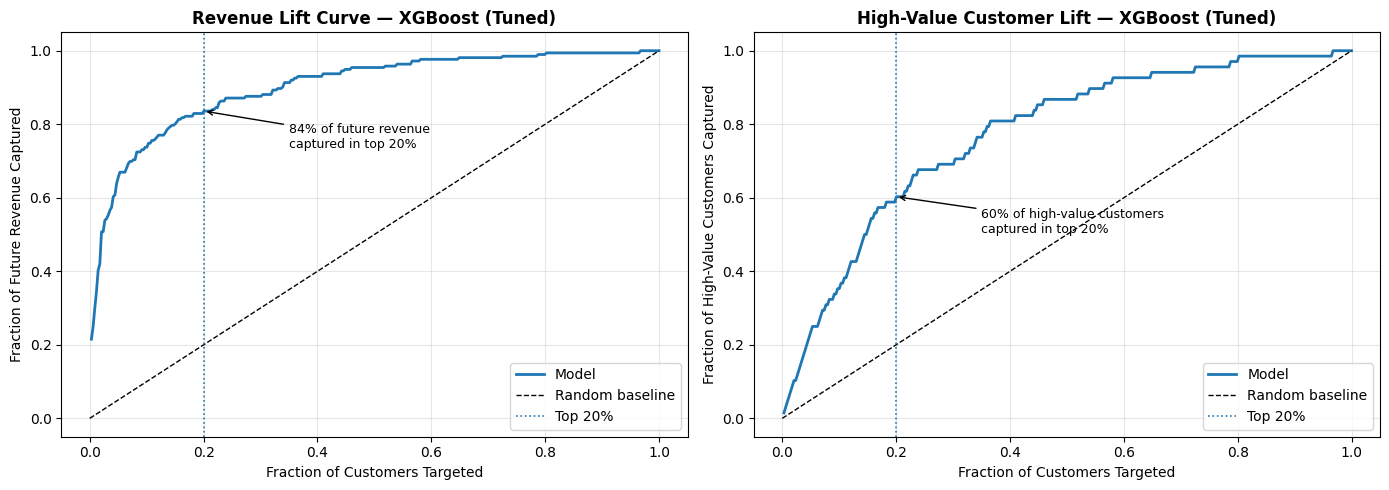

Model,MAE,RMSE,R2_YJ,MAPE_pos,Zero_Accuracy,Revenue_Capture,Pareto_Capture,ERS_Moderate,Cost_Efficiency,Wasted_Spend,ROI
Mean Predictor,"£2,197","£7,698",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
Median Predictor,"£1,886","£7,824",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
Two-Stage Baseline (Churn + LinReg),"£1,599","£6,409",-0.832,105.0%,53.39%,73.7%,65.1%,"£142,911",47.1%,£360,20916.3%
Random Forest,"£1,422","£4,606",0.641,136.3%,N/A,82.5%,86.0%,"£159,868",57.4%,£290,23410.0%
XGBoost,"£1,831","£7,340.50",0.089,132.4%,N/A,82.8%,88.4%,"£160,436",58.8%,£280,23493.5%
XGBoost (Tuned),"£1,589","£5,077.16",0.564,125.7%,N/A,83.6%,93.0%,"£162,046",60.3%,£270,23730.3%


In [ ]:
results_xgb_tuned = business_evaluation_clv(
    model_name="XGBoost (Tuned)",
    y_test=y_test_raw,
    y_pred_clv=y_pred_xgb_tuned,
    X_test=X_test,
    cost_per_contact=10,
    high_value_quantile=0.80
)


# Add TUNED XGBoost as a separate entry (keep original for comparison)
results_dict["XGBoost (Tuned)"] = {
    'MAE': f"£{mae_xgb_tuned:,.0f}",
    'RMSE': f"£{rmse_xgb_tuned:,.2f}",
    'R2_YJ': f"{r2_xgb_tuned:.3f}",
    'MAPE_pos': f"{mape_xgb_tuned:.1f}%",
    'Zero_Accuracy': "N/A",
    'Revenue_Capture': f"{results_xgb_tuned['revenue_capture']:.1%}",
    'Pareto_Capture':  f"{results_xgb_tuned['pareto_capture']:.1%}",
    'ERS_Moderate':    f"£{results_xgb_tuned['ers_moderate']:,.0f}",
    'Cost_Efficiency': f"{results_xgb_tuned['cost_efficiency']:.1%}",
    'Wasted_Spend':    f"£{results_xgb_tuned['wasted_spend']:,.0f}",
    'ROI': f"{(results_xgb_tuned['ers_moderate'] - results_xgb_tuned['total_spend']) / results_xgb_tuned['total_spend']:.1%}"
}

# Rebuild and display the table (now includes both XGBoost variants)
comparison_table = build_comparison_table_regression(results_dict)
comparison_table

CatBoost

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

cat_pipeline = clone(pipeline_tree)
cat_pipeline.set_params(model=CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
))
cat_pipeline.fit(X_train, y_train_raw)
y_pred_cat = np.clip(cat_pipeline.predict(X_test), 0, None)

In [ ]:
mae_cat  = mean_absolute_error(y_test_raw, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test_raw, y_pred_cat))
r2_cat   = r2_score(y_test_raw, y_pred_cat)

mask_pos = y_test_raw > 0
mape_cat = np.mean(np.abs(
    (y_test_raw[mask_pos] - y_pred_cat[mask_pos]) / y_test_raw[mask_pos]
)) * 100

print("=" * 60)
print("CatBoost — STATISTICAL METRICS")
print("=" * 60)
print(f"MAE  : £{mae_cat:,.2f}")
print(f"RMSE : £{rmse_cat:,.2f}")
print(f"R²   : {r2_cat:.4f}")
print(f"MAPE : {mape_cat:.2f}%")

CatBoost — STATISTICAL METRICS
MAE  : £1,428.58
RMSE : £4,320.35
R²   : 0.6843
MAPE : 136.54%


BUSINESS METRICS FOR CLV — CatBoost

Targeting top 19% of predicted CLV (exact count)
Actual high-value threshold: £2,026.46
Predicted threshold: £2,036.24

── Revenue Capture ───────────────────────────────────────
   Total high-value future revenue:  £553,906
   Captured by targeting:            £468,787  (84.63%)
   Missed:                           £85,119  (15.37%)

── Pareto Capture (Top 20% past spenders) ────────────────
   High-value among past top spenders: 43
   Caught by model:                    39  (90.70%)

── Expected Revenue Saved (ERS) ──────────────────────────
   Based on £468,787 of captured future revenue:
   Conservative (20%)        £93,757
   Moderate (35%)            £164,076
   Optimistic (50%)          £234,394

── Intervention Cost Efficiency ──────────────────────────
   Cost per contact:          £10
   Customers flagged:         68
   True high-value flagged:    42  (useful spend)
   False positives:            26  (wasted spend)
   Total spend:         

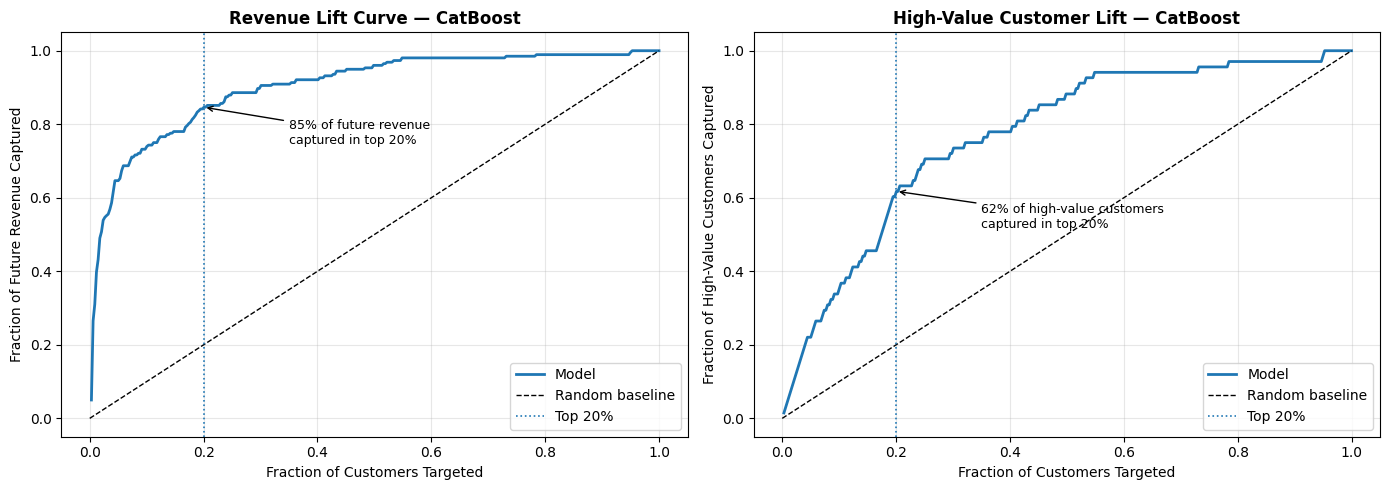

Model,MAE,RMSE,R2_YJ,MAPE_pos,Zero_Accuracy,Revenue_Capture,Pareto_Capture,ERS_Moderate,Cost_Efficiency,Wasted_Spend,ROI
Mean Predictor,"£2,197","£7,698",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
Median Predictor,"£1,886","£7,824",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
Two-Stage Baseline (Churn + LinReg),"£1,599","£6,409",-0.832,105.0%,53.39%,73.7%,65.1%,"£142,911",47.1%,£360,20916.3%
Random Forest,"£1,422","£4,606",0.641,136.3%,N/A,82.5%,86.0%,"£159,868",57.4%,£290,23410.0%
XGBoost,"£1,831","£7,340.50",0.089,132.4%,N/A,82.8%,88.4%,"£160,436",58.8%,£280,23493.5%
XGBoost (Tuned),"£1,589","£5,077.16",0.564,125.7%,N/A,83.6%,93.0%,"£162,046",60.3%,£270,23730.3%
CatBoost,"£1,429","£4,320.35",0.684,136.5%,N/A,84.6%,90.7%,"£164,076",61.8%,£260,24028.8%


In [ ]:
results_cat = business_evaluation_clv(
    model_name="CatBoost",
    y_test=y_test_raw,
    y_pred_clv=y_pred_cat,
    X_test=X_test,
    cost_per_contact=10,
    high_value_quantile=0.80
)


results_dict["CatBoost"] = {
    'MAE': f"£{mae_cat:,.0f}",
    'RMSE': f"£{rmse_cat:,.2f}",
    'R2_YJ': f"{r2_cat:.3f}",
    'MAPE_pos': f"{mape_cat:.1f}%",
    'Zero_Accuracy': "N/A",
    'Revenue_Capture': f"{results_cat['revenue_capture']:.1%}",
    'Pareto_Capture':  f"{results_cat['pareto_capture']:.1%}",
    'ERS_Moderate':    f"£{results_cat['ers_moderate']:,.0f}",
    'Cost_Efficiency': f"{results_cat['cost_efficiency']:.1%}",
    'Wasted_Spend':    f"£{results_cat['wasted_spend']:,.0f}",
    'ROI': f"{(results_cat['ers_moderate'] - results_cat['total_spend']) / results_cat['total_spend']:.1%}"
}

comparison_table = build_comparison_table_regression(results_dict)
comparison_table

CatBoost Optimized

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_cat = {
    'model__depth':         [4, 6, 8],
    'model__iterations':    [300, 500, 700],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__l2_leaf_reg':   [1, 3, 5]
}

cat_base = clone(pipeline_tree)
cat_base.set_params(model=CatBoostRegressor(
    random_seed=42,
    verbose=0
))

grid_cat = GridSearchCV(
    cat_base,
    param_grid_cat,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid_cat.fit(X_train, y_train_raw)

print(f"Best params: {grid_cat.best_params_}")
print(f"Best CV MAE: £{-grid_cat.best_score_:,.2f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params: {'model__depth': 8, 'model__iterations': 300, 'model__l2_leaf_reg': 1, 'model__learning_rate': 0.03}
Best CV MAE: £1,147.76


In [ ]:
# Predict with tuned CatBoost
y_pred_cat_tuned = np.clip(grid_cat.predict(X_test), 0, None)

# Statistical metrics
mae_cat_tuned   = mean_absolute_error(y_test_raw, y_pred_cat_tuned)
rmse_cat_tuned  = np.sqrt(mean_squared_error(y_test_raw, y_pred_cat_tuned))
r2_cat_tuned    = r2_score(y_test_raw, y_pred_cat_tuned)

mask_pos = y_test_raw > 0
mape_cat_tuned = np.mean(np.abs(
    (y_test_raw[mask_pos] - y_pred_cat_tuned[mask_pos]) / y_test_raw[mask_pos]
)) * 100

print("=" * 60)
print("CatBoost TUNED — STATISTICAL METRICS")
print("=" * 60)
print(f"MAE  : £{mae_cat_tuned:,.2f}")
print(f"RMSE : £{rmse_cat_tuned:,.2f}")
print(f"R²   : {r2_cat_tuned:.4f}")
print(f"MAPE : {mape_cat_tuned:.2f}%")

CatBoost TUNED — STATISTICAL METRICS
MAE  : £1,378.28
RMSE : £4,342.37
R²   : 0.6810
MAPE : 131.78%


BUSINESS METRICS FOR CLV — CatBoost (Tuned)

Targeting top 19% of predicted CLV (exact count)
Actual high-value threshold: £2,026.46
Predicted threshold: £2,068.92

── Revenue Capture ───────────────────────────────────────
   Total high-value future revenue:  £553,906
   Captured by targeting:            £471,141  (85.06%)
   Missed:                           £82,765  (14.94%)

── Pareto Capture (Top 20% past spenders) ────────────────
   High-value among past top spenders: 43
   Caught by model:                    39  (90.70%)

── Expected Revenue Saved (ERS) ──────────────────────────
   Based on £471,141 of captured future revenue:
   Conservative (20%)        £94,228
   Moderate (35%)            £164,899
   Optimistic (50%)          £235,570

── Intervention Cost Efficiency ──────────────────────────
   Cost per contact:          £10
   Customers flagged:         68
   True high-value flagged:    41  (useful spend)
   False positives:            27  (wasted spend)
   Total spend: 

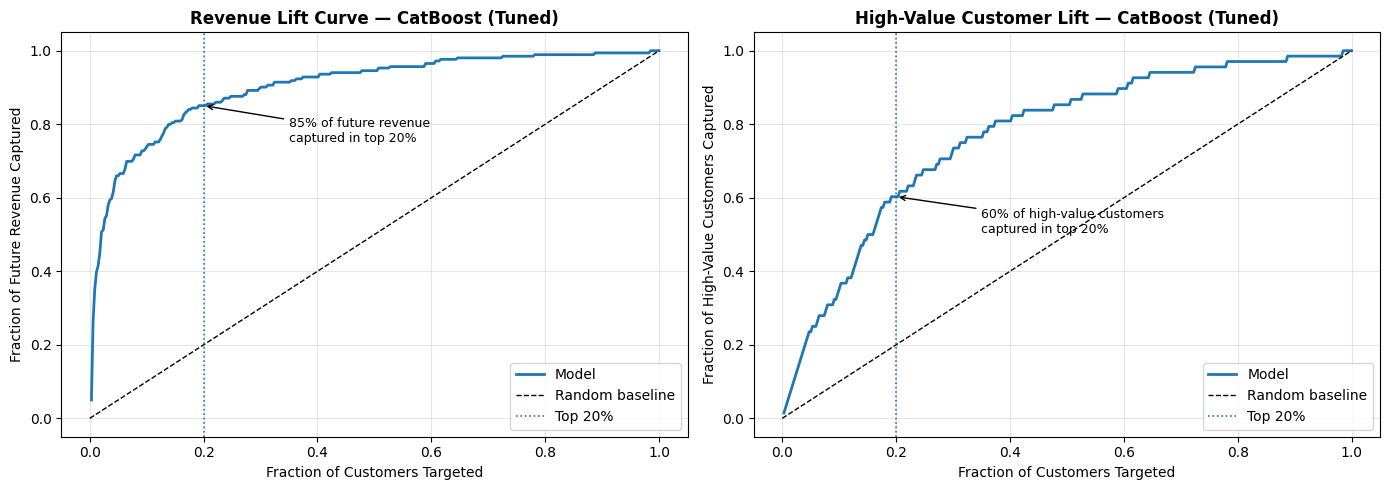

Model,MAE,RMSE,R2_YJ,MAPE_pos,Zero_Accuracy,Revenue_Capture,Pareto_Capture,ERS_Moderate,Cost_Efficiency,Wasted_Spend,ROI
Mean Predictor,"£2,197","£7,698",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
Median Predictor,"£1,886","£7,824",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
Two-Stage Baseline (Churn + LinReg),"£1,599","£6,409",-0.832,105.0%,53.39%,73.7%,65.1%,"£142,911",47.1%,£360,20916.3%
Random Forest,"£1,422","£4,606",0.641,136.3%,N/A,82.5%,86.0%,"£159,868",57.4%,£290,23410.0%
XGBoost,"£1,831","£7,340.50",0.089,132.4%,N/A,82.8%,88.4%,"£160,436",58.8%,£280,23493.5%
XGBoost (Tuned),"£1,589","£5,077.16",0.564,125.7%,N/A,83.6%,93.0%,"£162,046",60.3%,£270,23730.3%
CatBoost,"£1,429","£4,320.35",0.684,136.5%,N/A,84.6%,90.7%,"£164,076",61.8%,£260,24028.8%
CatBoost (Tuned),"£1,378","£4,342.37",0.681,131.8%,N/A,85.1%,90.7%,"£164,899",60.3%,£270,24149.9%


In [ ]:
results_cat_tuned = business_evaluation_clv(
    model_name="CatBoost (Tuned)",
    y_test=y_test_raw,
    y_pred_clv=y_pred_cat_tuned,
    X_test=X_test,
    cost_per_contact=10,
    high_value_quantile=0.80
)


results_dict["CatBoost (Tuned)"] = {
    'MAE': f"£{mae_cat_tuned:,.0f}",
    'RMSE': f"£{rmse_cat_tuned:,.2f}",
    'R2_YJ': f"{r2_cat_tuned:.3f}",
    'MAPE_pos': f"{mape_cat_tuned:.1f}%",
    'Zero_Accuracy': "N/A",
    'Revenue_Capture': f"{results_cat_tuned['revenue_capture']:.1%}",
    'Pareto_Capture':  f"{results_cat_tuned['pareto_capture']:.1%}",
    'ERS_Moderate':    f"£{results_cat_tuned['ers_moderate']:,.0f}",
    'Cost_Efficiency': f"{results_cat_tuned['cost_efficiency']:.1%}",
    'Wasted_Spend':    f"£{results_cat_tuned['wasted_spend']:,.0f}",
    'ROI': f"{(results_cat_tuned['ers_moderate'] - results_cat_tuned['total_spend']) / results_cat_tuned['total_spend']:.1%}"
}

comparison_table = build_comparison_table_regression(results_dict)
comparison_table

Tier 2 Model

In [ ]:
# ============================================================
# TWO-MODEL — TRAIN SPECIALIST (NON-WHALE ONLY)
# General CatBoost (cat_pipeline / y_pred_cat) is untouched
# ============================================================

cat_specialist = clone(pipeline_tree)
cat_specialist.set_params(model=CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
))
cat_specialist.fit(X_train_nonwhale, y_train_nonwhale)

print(f"Specialist trained on {len(X_train_nonwhale)} non-whale customers")

Specialist trained on 1082 non-whale customers


In [ ]:
# ============================================================
# TWO-MODEL — BLEND PREDICTIONS
# Whales    → general CatBoost (y_pred_cat)
# Non-whales → specialist CatBoost
# ============================================================

y_pred_specialist = np.clip(cat_specialist.predict(X_test), 0, None)

y_pred_twomodel = np.where(
    whale_test_mask,
    y_pred_cat,           # general model handles whales
    y_pred_specialist     # specialist handles everyone else
)

print(f"Blended predictions generated for {len(y_pred_twomodel)} customers")
print(f"  Whale predictions (from general):     {whale_test_mask.sum()}")
print(f"  Non-whale predictions (from specialist): {nonwhale_test_mask.sum()}")

Blended predictions generated for 339 customers
  Whale predictions (from general):     75
  Non-whale predictions (from specialist): 264


In [ ]:
# ============================================================
# TWO-MODEL — STATISTICAL METRICS
# ============================================================

mae_2m  = mean_absolute_error(y_test_raw, y_pred_twomodel)
rmse_2m = np.sqrt(mean_squared_error(y_test_raw, y_pred_twomodel))
r2_2m   = r2_score(y_test_raw, y_pred_twomodel)

mask_pos = y_test_raw > 0
mape_2m  = np.mean(np.abs(
    (y_test_raw[mask_pos] - y_pred_twomodel[mask_pos]) / y_test_raw[mask_pos]
)) * 100

print("=" * 60)
print("Two-Model CatBoost — STATISTICAL METRICS")
print("=" * 60)
print(f"MAE  : £{mae_2m:,.2f}")
print(f"RMSE : £{rmse_2m:,.2f}")
print(f"R²   : {r2_2m:.4f}")
print(f"MAPE : {mape_2m:.2f}%")

# Non-whale segment specifically — this is the number that matters
nonwhale_test_idx = np.where(nonwhale_test_mask)[0]
y_test_nonwhale   = y_test_raw.values[nonwhale_test_idx]
y_pred_nonwhale   = y_pred_twomodel[nonwhale_test_idx]

mae_nw = mean_absolute_error(y_test_nonwhale, y_pred_nonwhale)
r2_nw  = r2_score(y_test_nonwhale, y_pred_nonwhale)
print(f"\nNon-whale segment MAE : £{mae_nw:,.2f}")
print(f"Non-whale segment R²  : {r2_nw:.4f}")
print(f"(Compare these to general CatBoost on same segment to confirm specialist helps)")

Two-Model CatBoost — STATISTICAL METRICS
MAE  : £1,425.86
RMSE : £4,322.08
R²   : 0.6840
MAPE : 135.94%

Non-whale segment MAE : £620.82
Non-whale segment R²  : 0.1074
(Compare these to general CatBoost on same segment to confirm specialist helps)


BUSINESS METRICS FOR CLV — Two-Model CatBoost (General + Specialist)

Targeting top 19% of predicted CLV (exact count)
Actual high-value threshold: £2,026.46
Predicted threshold: £2,184.62

── Revenue Capture ───────────────────────────────────────
   Total high-value future revenue:  £553,906
   Captured by targeting:            £461,311  (83.28%)
   Missed:                           £92,595  (16.72%)

── Pareto Capture (Top 20% past spenders) ────────────────
   High-value among past top spenders: 43
   Caught by model:                    37  (86.05%)

── Expected Revenue Saved (ERS) ──────────────────────────
   Based on £461,311 of captured future revenue:
   Conservative (20%)        £92,262
   Moderate (35%)            £161,459
   Optimistic (50%)          £230,655

── Intervention Cost Efficiency ──────────────────────────
   Cost per contact:          £10
   Customers flagged:         68
   True high-value flagged:    39  (useful spend)
   False positives:            29  (waste

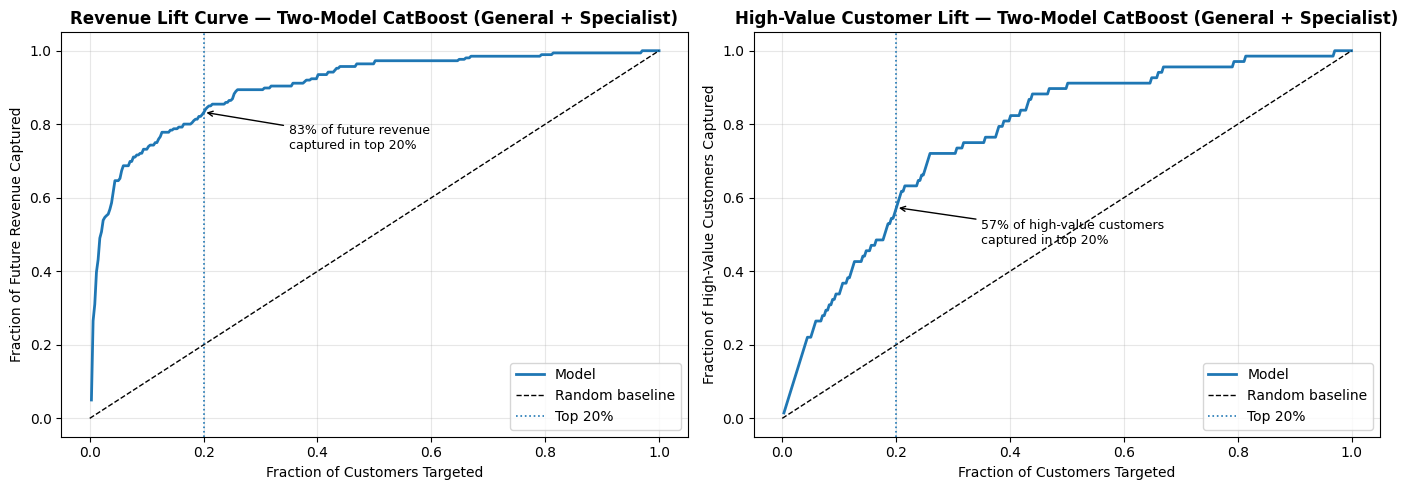

Model,MAE,RMSE,R2_YJ,MAPE_pos,Zero_Accuracy,Revenue_Capture,Pareto_Capture,ERS_Moderate,Cost_Efficiency,Wasted_Spend,ROI
Mean Predictor,"£2,197","£7,698",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
Median Predictor,"£1,886","£7,824",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
Two-Stage Baseline (Churn + LinReg),"£1,599","£6,409",-0.832,105.0%,53.39%,73.7%,65.1%,"£142,911",47.1%,£360,20916.3%
Random Forest,"£1,422","£4,606",0.641,136.3%,N/A,82.5%,86.0%,"£159,868",57.4%,£290,23410.0%
XGBoost,"£1,831","£7,340.50",0.089,132.4%,N/A,82.8%,88.4%,"£160,436",58.8%,£280,23493.5%
XGBoost (Tuned),"£1,589","£5,077.16",0.564,125.7%,N/A,83.6%,93.0%,"£162,046",60.3%,£270,23730.3%
CatBoost,"£1,429","£4,320.35",0.684,136.5%,N/A,84.6%,90.7%,"£164,076",61.8%,£260,24028.8%
CatBoost (Tuned),"£1,378","£4,342.37",0.681,131.8%,N/A,85.1%,90.7%,"£164,899",60.3%,£270,24149.9%
Two-Model CatBoost,"£1,426","£4,322",0.684,135.9%,N/A,83.3%,86.0%,"£161,459",57.4%,£290,23643.9%


In [ ]:
# ============================================================
# TWO-MODEL — BUSINESS METRICS + UPDATED TABLE
# ============================================================

y_pred_twomodel_series = pd.Series(y_pred_twomodel, index=X_test.index)

results_2m = business_evaluation_clv(
    model_name="Two-Model CatBoost (General + Specialist)",
    y_test=y_test_raw,
    y_pred_clv=y_pred_twomodel_series,
    X_test=X_test,
    cost_per_contact=10,
    high_value_quantile=0.80
)

roi_2m = (results_2m['ers_moderate'] - results_2m['total_spend']) / results_2m['total_spend']

results_dict["Two-Model CatBoost"] = {
    'MAE':              f"£{mae_2m:,.0f}",
    'RMSE':             f"£{rmse_2m:,.0f}",
    'R2_YJ':            f"{r2_2m:.3f}",
    'MAPE_pos':         f"{mape_2m:.1f}%",
    'Zero_Accuracy':    "N/A",
    'Revenue_Capture':  f"{results_2m['revenue_capture']:.1%}",
    'Pareto_Capture':   f"{results_2m['pareto_capture']:.1%}",
    'ERS_Moderate':     f"£{results_2m['ers_moderate']:,.0f}",
    'Cost_Efficiency':  f"{results_2m['cost_efficiency']:.1%}",
    'Wasted_Spend':     f"£{results_2m['wasted_spend']:,.0f}",
    'ROI':              f"{roi_2m:.1%}"
}

build_comparison_table_regression(results_dict)

Final Predictions

In [ ]:
# ============================================================
# FINAL MODEL — RETRAIN ON FULL DATASET
# ============================================================

cat_final = clone(pipeline_tree)
cat_final.set_params(model=CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
))
cat_final.fit(X_clv, y_raw)  # full dataset, all 1692 customers

# Predict CLV for all customers
clv_predictions_all = np.clip(cat_final.predict(X_clv), 0, None)

# Build client-facing output
client_output = pd.DataFrame({
    'CustomerID':    clv_df['CustomerID'],
    'predicted_clv': clv_predictions_all
})

# Add CLV tier labels
def assign_clv_tier(series):
    nonzero = series[series > 0]
    p33 = nonzero.quantile(0.33)
    p67 = nonzero.quantile(0.67)
    conditions = [
        series == 0,
        (series > 0) & (series <= p33),
        (series > p33) & (series <= p67),
        series > p67
    ]
    return np.select(conditions, ['Zero', 'Low', 'Mid', 'High'], default='Zero')

client_output['clv_tier'] = assign_clv_tier(
    pd.Series(clv_predictions_all)
)

print(f"Predictions generated for {len(client_output)} customers")
print(f"\nCLV tier distribution:")
print(client_output['clv_tier'].value_counts())
print(f"\nPredicted CLV range: £{clv_predictions_all.min():,.0f} — £{clv_predictions_all.max():,.0f}")
print(f"Predicted CLV mean:  £{clv_predictions_all.mean():,.0f}")

# Export
client_output.to_csv('clv_predictions.csv', index=False)
print("\nSaved: clv_predictions.csv")

Predictions generated for 1692 customers

CLV tier distribution:
clv_tier
Mid     572
Low     557
High    557
Zero      6
Name: count, dtype: int64

Predicted CLV range: £0 — £176,231
Predicted CLV mean:  £1,824

Saved: clv_predictions.csv


Action matrix


In [ ]:
# ============================================================
# ACTION MATRIX — SETUP
# ============================================================

# Get churn probabilities on full dataset
churn_probs_all = churn_model_general.predict_proba(X_churn)[:, 1]

# Build action dataframe
action_df = pd.DataFrame({
    'CustomerID':    clv_df['CustomerID'],
    'predicted_clv': clv_predictions_all,
    'churn_prob':    churn_probs_all
}, index=clv_df.index)

# Use medians as quadrant boundaries
clv_median   = action_df['predicted_clv'].median()
churn_median = action_df['churn_prob'].median()

print(f"CLV split point:   £{clv_median:,.0f}")
print(f"Churn split point: {churn_median:.2f}")

# Assign quadrants
def assign_quadrant(row):
    high_clv   = row['predicted_clv'] >= clv_median
    high_churn = row['churn_prob']    >= churn_median
    if high_clv and high_churn:
        return 'Q1 — Intervene Now'
    elif high_clv and not high_churn:
        return 'Q2 — Nurture'
    elif not high_clv and high_churn:
        return 'Q3 — Let Go'
    else:
        return 'Q4 — Monitor'

action_df['segment'] = action_df.apply(assign_quadrant, axis=1)

# Summary
print(f"\nAction Matrix Distribution:")
print(action_df['segment'].value_counts())
print(f"\nRevenue at stake per segment:")
segment_revenue = action_df.groupby('segment')['predicted_clv'].agg(['count', 'sum', 'mean'])
segment_revenue.columns = ['customers', 'total_clv', 'avg_clv']
print(segment_revenue.round(0))

# Export
action_df.to_csv('action_matrix.csv', index=False)
print("\nSaved: action_matrix.csv")

CLV split point:   £848
Churn split point: 0.50

Action Matrix Distribution:
segment
Q3 — Let Go           714
Q2 — Nurture          714
Q1 — Intervene Now    132
Q4 — Monitor          132
Name: count, dtype: int64

Revenue at stake per segment:
                    customers  total_clv  avg_clv
segment                                          
Q1 — Intervene Now        132   178323.0   1351.0
Q2 — Nurture              714  2496022.0   3496.0
Q3 — Let Go               714   323945.0    454.0
Q4 — Monitor              132    88757.0    672.0

Saved: action_matrix.csv


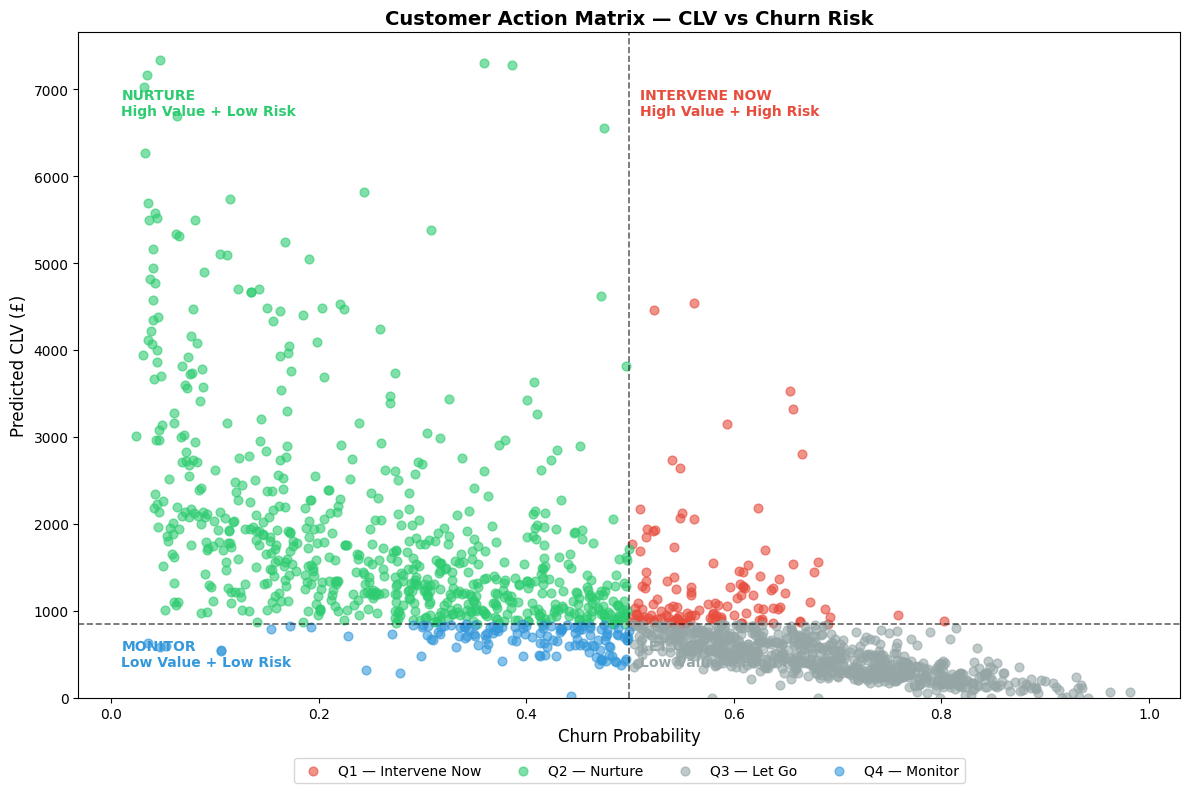

In [ ]:
# ============================================================
# ACTION MATRIX — VISUALIZATION
# ============================================================

colors = {
    'Q1 — Intervene Now': '#e74c3c',
    'Q2 — Nurture':       '#2ecc71',
    'Q3 — Let Go':        '#95a5a6',
    'Q4 — Monitor':       '#3498db'
}

plt.figure(figsize=(12, 8))

for segment, group in action_df.groupby('segment'):
    plt.scatter(
        group['churn_prob'],
        group['predicted_clv'],
        c=colors[segment],
        label=segment,
        alpha=0.6,
        s=40
    )

# Quadrant lines
plt.axvline(x=churn_median, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
plt.axhline(y=clv_median,   color='black', linestyle='--', linewidth=1.2, alpha=0.6)

# Quadrant labels
ymax = action_df['predicted_clv'].quantile(0.97)  # avoid whale distortion
plt.text(churn_median + 0.01, ymax * 0.92, 'INTERVENE NOW\nHigh Value + High Risk',
         fontsize=10, color='#e74c3c', fontweight='bold')
plt.text(0.01, ymax * 0.92, 'NURTURE\nHigh Value + Low Risk',
         fontsize=10, color='#2ecc71', fontweight='bold')
plt.text(churn_median + 0.01, ymax * 0.05, 'LET GO\nLow Value + High Risk',
         fontsize=10, color='#95a5a6', fontweight='bold')
plt.text(0.01, ymax * 0.05, 'MONITOR\nLow Value + Low Risk',
         fontsize=10, color='#3498db', fontweight='bold')

plt.xlabel('Churn Probability', fontsize=12)
plt.ylabel('Predicted CLV (£)', fontsize=12)
plt.title('Customer Action Matrix — CLV vs Churn Risk', fontsize=14, fontweight='bold')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=4)
plt.ylim(bottom=0, top=ymax * 1.05)
plt.tight_layout()
plt.show()

# Business Recommendations & Strategic Guidance

---

## Immediate Actions (Next 30 Days)

### Priority 1 — Protect the Top 1%
16 customers generate 28% of all future revenue. These customers should be known by name
to someone in the business. Assign a dedicated account owner to each one. Do not let
these relationships be managed through generic email campaigns. The cost of losing one
£50,000 customer vastly exceeds the cost of a dedicated relationship manager.

### Priority 2 — Act on Q1 Customers First
The action matrix identifies customers with both high predicted CLV and high churn risk.
These are the most time-sensitive segment — valuable customers already showing disengagement
signals. Recommended intervention: personal outreach within 2 weeks, not a bulk email.
The model flags who. The business decides how.

### Priority 3 — Do Not Waste Budget on Q3
Low CLV + high churn risk customers are not worth expensive retention spend. An automated
low-cost email at most. Redirect that budget to Q1. This is where most businesses leak
retention spend — they treat all at-risk customers equally regardless of value.

---

## Segment-Specific Recommendations

### Q1 — Intervene Now (High CLV + High Churn Risk)
These customers are your most urgent priority. They are valuable and leaving.

- Assign personal outreach — phone or direct email, not automated
- Offer early access to new products or exclusive pricing
- Ask directly why engagement has dropped — the feedback is as valuable as the retention
- Set a 30-day follow-up regardless of response
- Budget: justify up to £50–£200 per customer given predicted CLV at stake

### Q2 — Nurture (High CLV + Low Churn Risk)
Stable, valuable customers. The risk here is neglect — assuming loyal customers stay loyal
without investment.

- Enroll in a VIP or loyalty program if one exists
- Prioritise for upsell and cross-category introduction
- Send personalised product recommendations based on purchase history
- Check in quarterly — not to retain, but to deepen the relationship
- These customers are your best source of referrals

### Q3 — Let Go (Low CLV + High Churn Risk)
Do not invest heavily here. Their predicted future value does not justify expensive
intervention.

- One automated re-engagement email maximum
- If no response within 30 days, move them to an inactive list
- Analyse what these customers have in common — understanding why low-value customers
  churn may inform acquisition strategy (stop acquiring customers who look like this)

### Q4 — Monitor (Low CLV + Low Churn Risk)
Stable but small. No action needed now, but do not ignore them permanently.

- Include in standard marketing communications
- Watch for sudden increases in purchase frequency — these customers can graduate to
  higher tiers and the model should be re-run periodically to catch this
- Low cost to maintain, no cost to ignore short-term

---

## Revenue Protection Estimates

Based on the moderate retention assumption (35% of captured revenue saved through
intervention), targeting the top 20% of customers by predicted CLV is expected to
protect approximately £164,000 in future revenue at a contact cost of £680. This
represents a return of approximately £235 for every £1 spent on outreach.

These are conservative estimates. The actual return depends on:
- Quality of intervention (personal vs automated)
- Timing (earlier is always better once churn signals appear)
- Product or pricing levers available to the business

---

## Strategic Recommendations (Next 90 Days)

### Build a Monthly CLV Refresh Cycle
Customer value is not static. A customer who looked like Q4 three months ago may now
show Q1 signals after a large order. The model should be re-run monthly on updated
transaction data so the action matrix stays current. The pipeline is already built —
this is an operational question, not a technical one.

### Track Intervention Outcomes
The model tells you who to contact. Start recording what happens next. Did the Q1
customer who received outreach retain? Did the Q2 customer upsell? Within 6 months
you will have enough outcome data to measure the actual revenue impact of the model
and to tune the intervention strategy. Without tracking, the model runs blind.

### Identify Your Acquisition Problem
The bottom 20% of customers by past spend generate less than 2% of future revenue.
Some of these customers cost more to serve than they generate. Pull the acquisition
channel for your lowest-CLV customers and compare it to your highest-CLV customers.
If a meaningful pattern exists — certain campaigns, geographies, or product entry
points consistently produce low-value customers — stop spending acquisition budget
there and redirect it toward channels that produce customers who look like your top tier.

### Use CLV in Acquisition Pricing
If the business runs paid advertising or affiliate campaigns with a cost-per-acquisition
model, the predicted CLV framework allows you to bid differently for different customer
types. A customer likely to spend £5,000 over 6 months justifies a higher acquisition
cost than one likely to spend £200. This is a medium-term opportunity once the model
has been validated against actual outcomes.

---

## Data Improvement Roadmap

The current model hits a performance ceiling because transaction data alone cannot
separate mid-value customers. The following data additions are ranked by impact and
feasibility.

### High Impact — Collect Immediately

**Customer type flag (B2B vs individual)**
The single highest-value addition to this dataset. A small retailer and an individual
consumer can have identical transaction histories but completely different growth
trajectories. Even a simple binary flag — is this a business account or a personal
account — would give the model a fundamental signal it currently cannot see.
*How to collect:* Registration form field, or infer from order quantities above a threshold.

**Purchase category tags**
Currently `unique_products` counts how many distinct products were bought but not what
categories they span. A customer buying across 5 categories has a fundamentally different
relationship with the business than one buying the same item from 5 subcategories. Category
diversity is a strong loyalty signal.
*How to collect:* Map existing product codes to a category taxonomy — this is a one-time
data enrichment exercise, not ongoing collection.

### Medium Impact — Plan Within 6 Months

**Customer acquisition date and channel**
How long has this customer been active and how did they arrive? A 3-year customer
spending £600 is very different from a 3-month customer spending £600. The current
`customer_lifespan` feature partially captures this but acquisition channel is absent
entirely.
*How to collect:* UTM tracking on marketing campaigns, referral source field at registration.

**Seasonal purchase pattern**
Does this customer buy year-round or only in specific months? A consistent buyer is more
valuable than a seasonal one with identical total spend. The current dataset covers a
limited window — with 2+ years of history this feature becomes computable automatically.
*How to collect:* No new data needed — just longer history.

**Return reason codes**
`return_count` and `return_rate` are already in the model but carry no context. A customer
returning items due to quality issues is a different risk profile than one returning due to
overordering and adjusting quantities. Return reason codes would make this signal much richer.
*How to collect:* Add a required field to the returns process.

### Lower Priority — Consider for V2

**Company size for business accounts**
For B2B customers, company headcount or revenue tier is a strong predictor of future spend
ceiling. A startup spending £500 today may be worth £20,000 in two years. A mature SME
spending £500 is likely near their ceiling.
*How to collect:* Firmographic data append service (Companies House API for UK businesses,
or a data provider like Clearbit).

**Communication engagement data**
Do customers open emails? Click through to the site? Engagement with marketing
communications is a leading indicator of purchase intent and would significantly improve
the churn signal for mid-value customers.
*How to collect:* Email platform integration — already tracked by most providers,
just needs to be joined to the customer record.

---

## What Good Performance Looks Like in 12 Months

With the current model running monthly and the data improvements above implemented,
realistic targets for the next annual review:

| Metric | Current | 12-month target |
|---|---|---|
| Tier 1 revenue capture | 96.5% | 97%+ (marginal, already strong) |
| Tier 2 revenue capture | 15.5% | 35–45% (with category + B2B flag data) |
| Action matrix refresh | One-time | Monthly automated |
| Intervention tracking | Not started | 6 months of outcome data |
| Model R² | 0.684 | 0.75+ (with richer features) |

The Tier 2 number is the one to watch. Everything else is already performing well.
Mid-value customer prediction is where the business leaves the most money on the table
and where better data has the clearest path to better outcomes.

---

## Summary for the Client

This analysis gives you three things:

**1. A ranked list of who to protect.**
Every customer in your base has a predicted future value and a churn risk score. The action
matrix tells you exactly which quadrant they fall into and what action to take. Start with
Q1 — the high-value customers already going quiet.

**2. A revenue protection estimate.**
Targeting the top 20% of customers by predicted value, with a moderate assumption on
retention lift, is expected to protect approximately £164,000 in future revenue at a
contact cost under £700. That is not a guarantee — it is a framework for prioritising
where human attention and budget go.

**3. A roadmap for making the model better.**
The current model is limited by the data available. Adding customer type, product
categories, and acquisition channel data would meaningfully improve mid-value customer
prediction — the segment where prediction is currently weakest and where the most
unrealised revenue sits.

The model does not replace judgment. It tells you who deserves your attention first.

In [ ]:
for f in sorted(os.listdir("report_figures")):
       print(f)

clv_distribution_raw.png
customer_action_matrix_clv_vs_churn_risk.png
customer_count_zero_vs_non_zero_clv.png
feature_correlation_with_raw_clv_including_zero_spend_customers.png
feature_feature_pearson_correlation_multicollinearity_check.png
monetary_log_y.png
monetary_vs_clv_log_y_spearman_0_612.png
monetary_vs_clv_spearman_0_612.png
raw_clv_skew_16_12.png
revenue_concentration_lorenz_curve.png
revenue_lift_curve_catboost.png
revenue_lift_curve_catboost_tuned.png
revenue_lift_curve_random_forest_single_stage_clv.png
revenue_lift_curve_two_model_catboost_general_specialist.png
revenue_lift_curve_two_stage_baseline_churn_linreg.png
revenue_lift_curve_xgboost_single_stage_clv.png
revenue_lift_curve_xgboost_tuned.png


In [ ]:
shutil.make_archive("notebook4_figures", 'zip', "report_figures")
   from google.colab import files
   files.download("notebook4_figures.zip")

SyntaxError: invalid syntax (1382314361.py, line 2)